In [ ]:
# ─── CELL 0: Title ───────────────────────────────────────────────────────────
md("""# Ajuste Dinámico de Curvas de Rendimiento: NS y NSS por OLS
## Nelson-Siegel · Nelson-Siegel-Svensson · Mínimos Cuadrados Ordinarios · Análisis Post-Ajuste

### Metodología
El ajuste diario estima los parámetros $\\boldsymbol{\\beta}_t$ para cada fecha $t$ vía OLS,
con dos modos para los parámetros de forma $\\tau$:

| Modo | Descripción |
|------|-------------|
| **`tau_flexible`** | Grid Search: $\\tau_t^* = \\arg\\min_{\\tau} \\text{SSE}(\\tau, t)$ — $\\tau$ óptimo fecha a fecha |
| **`tau_fijo`** | $\\tau$ pre-fijado; se estima $\\tau^*$ global que minimiza SSE total sobre toda la muestra |

**Modelo Nelson-Siegel (NS):**
$$y(m) = \\beta_0 + \\beta_1 \\cdot \\frac{1-e^{-m/\\tau}}{m/\\tau} + \\beta_2 \\cdot \\left(\\frac{1-e^{-m/\\tau}}{m/\\tau} - e^{-m/\\tau}\\right)$$

**Modelo Nelson-Siegel-Svensson (NSS):**
$$y(m) = \\beta_0 + \\beta_1 \\cdot \\frac{1-e^{-m/\\tau_1}}{m/\\tau_1} + \\beta_2 \\cdot \\left(\\frac{1-e^{-m/\\tau_1}}{m/\\tau_1} - e^{-m/\\tau_1}\\right) + \\beta_3 \\cdot \\left(\\frac{1-e^{-m/\\tau_2}}{m/\\tau_2} - e^{-m/\\tau_2}\\right)$$
""")


In [3]:
# ─── CELL 1: Imports ─────────────────────────────────────────────────────────

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.gridspec as gridspec
from matplotlib.colors import TwoSlopeNorm, LinearSegmentedColormap
from scipy import stats
from pathlib import Path
import warnings, time, os
warnings.filterwarnings('ignore')

# ── Paletas de color ───────────────────────────────────────────────────────────
COLORES_FACTOR = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
COLORES_TAU    = ['#9467bd', '#8c564b']

print("Imports OK")



Imports OK


In [4]:
# ─── CELL 2: Data loading ─────────────────────────────────────────────────────
"""\
## CELDA 1: Carga y preparación de datos

### Formato esperado del archivo (`datos/curvas_panel_historico.csv`)
| Columna | Tipo | Ejemplo |
|---------|------|---------|
| `fecha` | AAAA-MM-DD | `2015-01-05` |
| `r_1yr` | decimal | `0.0512` |
| `r_2yr` | decimal | `0.0538` |
| ... | ... | ... |
| `r_30yr`| decimal | `0.0720` |

El parámetro `PLAZOS_ACTIVOS` permite seleccionar qué nodos de madurez usar en el ajuste.
"""

# ══════════════════════════════════════════════════════════════════════════════
# PARÁMETROS DE USUARIO — editar según necesidad
# ══════════════════════════════════════════════════════════════════════════════


def encontrar_raiz_proyecto(inicio: Path | None = None) -> Path:
    inicio = (inicio or Path.cwd()).resolve()
    for ruta in [inicio, *inicio.parents]:
        if (ruta / "TES_colombia").exists() or (ruta / "Datos").exists():
            return ruta
    return inicio


RAIZ_PROYECTO = encontrar_raiz_proyecto()
RUTA_DATOS = RAIZ_PROYECTO / "TES_colombia" / "curvas_panel_historico_limpio.csv"

# Plazos (años) que se usarán en el ajuste — PARAMETRIZABLE
PLAZOS_ACTIVOS = [1, 2, 3, 5, 7, 10, 15]

FECHA_INICIO = "2015-01-01"
FECHA_FIN    = "2026-03-20"

# ══════════════════════════════════════════════════════════════════════════════

# Columnas esperadas para cada plazo
_col = lambda n: f"r_{n}yr"

if RUTA_DATOS.exists():
    raw = pd.read_csv(RUTA_DATOS, parse_dates=["fecha"])
    raw = raw[(raw["fecha"] >= FECHA_INICIO) & (raw["fecha"] <= FECHA_FIN)].reset_index(drop=True)
    
    yield_cols = [_col(n) for n in PLAZOS_ACTIVOS]
    missing = [c for c in yield_cols if c not in raw.columns]
    if missing:
        raise ValueError(f"Columnas no encontradas en el CSV: {missing}")
    
    df_clean   = raw[["fecha"] + yield_cols].dropna()
    dates_dt   = df_clean["fecha"].values
    yields_data = df_clean[yield_cols].values.astype(float)
    maturities  = np.array(PLAZOS_ACTIVOS, dtype=float)
    T, N        = yields_data.shape
    print(f"Datos reales cargados: {T} fechas × {N} plazos")
    print(f"  Raíz proyecto  : {RAIZ_PROYECTO}")
    print(f"  Archivo datos  : {RUTA_DATOS}")
    print(f"  Plazos activos : {PLAZOS_ACTIVOS}")
    print(f"  Período        : {str(dates_dt[0])[:10]} → {str(dates_dt[-1])[:10]}")

else:
    # ── Datos sintéticos de demostración ──────────────────────────────────────
    print(f"⚠  Archivo '{RUTA_DATOS}' no encontrado — usando datos SINTÉTICOS de demo.")
    np.random.seed(42)
    dates_dt    = pd.date_range("2015-01-05", "2026-01-01", freq="B").values
    maturities  = np.array(PLAZOS_ACTIVOS, dtype=float)
    T, N        = len(dates_dt), len(maturities)

    # Curva NS con parámetros que evolucionan suavemente
    beta0 = 0.06 + 0.01*np.sin(np.linspace(0, 4*np.pi, T))
    beta1 = -0.02 + 0.005*np.cos(np.linspace(0, 3*np.pi, T))
    beta2 = 0.015 + 0.005*np.sin(np.linspace(0, 2*np.pi, T))
    tau   = 1.5

    def _ns(m, b0, b1, b2, t):
        mt = m/t; e = np.exp(-mt); c = (1-e)/mt
        return b0 + b1*c + b2*(c-e)

    yields_data = np.array([
        _ns(maturities, beta0[t], beta1[t], beta2[t], tau)
        + np.random.normal(0, 0.001, N)
        for t in range(T)
    ])
    print(f"  Datos sintéticos: {T} fechas × {N} plazos")
    print(f"  Plazos activos  : {PLAZOS_ACTIVOS}")



Datos reales cargados: 2735 fechas × 7 plazos
  Raíz proyecto  : C:\proyectos\repo_kevin
  Archivo datos  : C:\proyectos\repo_kevin\TES_colombia\curvas_panel_historico_limpio.csv
  Plazos activos : [1, 2, 3, 5, 7, 10, 15]
  Período        : 2015-01-02 → 2026-03-20


In [7]:
# ─── CELL 3: Loading functions ────────────────────────────────────────────────
"""\
## CELDA 2: Cargas Nelson-Siegel y Svensson

$$H_{NS}(\\tau)_n = \\left[1,\\; \\frac{1-e^{-m_n/\\tau}}{m_n/\\tau},\\; \\frac{1-e^{-m_n/\\tau}}{m_n/\\tau}-e^{-m_n/\\tau}\\right]$$

$$H_{NSS}(\\tau_1,\\tau_2)_n = \\left[H_{NS}(\\tau_1)_n,\\; \\frac{1-e^{-m_n/\\tau_2}}{m_n/\\tau_2}-e^{-m_n/\\tau_2}\\right]$$
"""

def ns_loadings(maturities, tau1):
    """Cargas Nelson-Siegel. Shape (N, 3). [nivel, pendiente, curvatura]"""
    m  = np.asarray(maturities, dtype=float)
    mt = m / tau1
    e  = np.exp(-mt)
    c  = (1.0 - e) / mt
    return np.column_stack([np.ones_like(m), c, c - e])


def nss_loadings(maturities, tau1, tau2):
    """Cargas Nelson-Siegel-Svensson. Shape (N, 4). [nivel, pendiente, curv1, curv2]"""
    m   = np.asarray(maturities, dtype=float)
    mt1 = m / tau1;  mt2 = m / tau2
    e1  = np.exp(-mt1);  e2 = np.exp(-mt2)
    c1  = (1.0 - e1) / mt1
    return np.column_stack([np.ones_like(m), c1, c1 - e1, (1.0 - e2)/mt2 - e2])


def get_loadings(maturities, tau1, tau2=None, model='NS'):
    """Wrapper unificado."""
    return ns_loadings(maturities, tau1) if model == 'NS' else nss_loadings(maturities, tau1, tau2)






In [8]:
# ─── CELL 4: OLS core ─────────────────────────────────────────────────────────
"""\
## CELDA 3: OLS puntual y residual maker

### OLS fecha a fecha
Dado $H_t$ (la matriz de cargas para la fecha $t$), estimamos:
$$\\hat{\\boldsymbol{\\beta}}_t = (H_t^\\top H_t)^{-1} H_t^\\top \\mathbf{y}_t$$

### Proyector de residuos (para grid search)
$$M_\\tau = I - H(\\tau)\\left[H(\\tau)^\\top H(\\tau)\\right]^{-1}H(\\tau)^\\top$$
$$\\text{SSE}(\\tau) = \\text{tr}\\!\\left(M_\\tau \\, \\Sigma\\right)$$
"""

def ols_one_date(y, H):
    """
    OLS: beta = (H'H)^-1 H' y
    Retorna (beta, fitted, residual) o None si H es singular.
    """
    HtH = H.T @ H
    if np.linalg.cond(HtH) > 1e12:
        return None
    try:
        beta   = np.linalg.solve(HtH, H.T @ y)
        fitted = H @ beta
        return beta, fitted, y - fitted
    except np.linalg.LinAlgError:
        return None


def _residual_maker(H):
    """I - H(H'H)^{-1}H' (proyector ortogonal al espacio columna de H)."""
    N, k = H.shape
    HtH  = H.T @ H
    if np.linalg.cond(HtH) > 1e12:
        return None
    try:
        return np.eye(N) - H @ np.linalg.solve(HtH, H.T)
    except np.linalg.LinAlgError:
        return None


print("Funciones OLS y residual-maker definidas.")



Funciones OLS y residual-maker definidas.


In [9]:

# ─── CELL 5: Grid Search tau flexible ─────────────────────────────────────────

## CELDA 4: Búsqueda de $\\tau$ — Modo Flexible (Grid Search fecha a fecha)
"""
Para cada $t$ se minimiza la SSE usando el proyector precomputado y sumas acumuladas
de $\\mathbf{y}_s\\mathbf{y}_s^\\top$, lo que permite evaluar toda la grilla de $\\tau$
de forma vectorizada por fecha.
"""

def _build_YYt_cumsum(yields):
    """Sumas acumuladas de y_s y_s'. Retorna (T+1, N, N)."""
    T, N = yields.shape
    YYt  = np.zeros((T + 1, N, N))
    for t in range(T):
        YYt[t+1] = YYt[t] + np.outer(yields[t], yields[t])
    return YYt


def grid_search_tau_ns(yields, maturities, tau1_grid, window_size=None):
    """
    Grid search de tau1 para NS, fecha a fecha.

    Si window_size es None usa toda la historia hasta t.
    Retorna tau1_t (T,), sse_t (T,), sse_grid_t (T, G1).
    Retorna tau1_t (T,), sse_t (T,), sse_grid_t (T, G1).
    """
    T, N = yields.shape
    G1   = len(tau1_grid)
    k    = 3

    M_list = []
    for tau1 in tau1_grid:
        H  = ns_loadings(maturities, tau1)
        Mv = _residual_maker(H)
        M_list.append(Mv if Mv is not None else np.eye(N))
    M_arr   = np.stack(M_list, axis=0)       # (G1, N, N)
    YYt_cum = _build_YYt_cumsum(yields)
    default = G1 // 2

    tau1_t     = np.zeros(T)
    sse_t      = np.zeros(T)
    sse_grid_t = np.full((T, G1), np.nan)

    for t in range(T):
        if window_size is None:
            Sigma = YYt_cum[t+1]; n_win = t+1
        else:
            t0    = max(0, t - window_size + 1)
            Sigma = YYt_cum[t+1] - YYt_cum[t0]; n_win = t-t0+1

        if n_win < k + 2:
            tau1_t[t] = tau1_grid[default]; continue

        sse_vec       = np.einsum('gij,ji->g', M_arr, Sigma)
        sse_grid_t[t] = sse_vec
        best_g        = np.argmin(sse_vec)
        tau1_t[t]     = tau1_grid[best_g]
        sse_t[t]      = sse_vec[best_g]

    return tau1_t, sse_t, sse_grid_t


def grid_search_tau_nss(yields, maturities, tau1_grid, tau2_grid,
                        window_size=None, sep_min=0.15):
    """
    Grid search de (tau1, tau2) para NSS, fecha a fecha.
    """
    T, N   = yields.shape
    G1, G2 = len(tau1_grid), len(tau2_grid)
    k      = 4

    M_arr = np.zeros((G1, G2, N, N))
    valid = np.zeros((G1, G2), dtype=bool)
    for i, tau1 in enumerate(tau1_grid):
        for j, tau2 in enumerate(tau2_grid):
            if abs(tau1 - tau2) < sep_min:
                continue
            H  = nss_loadings(maturities, tau1, tau2)
            Mv = _residual_maker(H)
            if Mv is not None:
                M_arr[i, j] = Mv; valid[i, j] = True

    YYt_cum = _build_YYt_cumsum(yields)
    di, dj  = G1//2, G2//4

    tau1_t = np.zeros(T); tau2_t = np.zeros(T); sse_t = np.zeros(T)

    for t in range(T):
        if window_size is None:
            Sigma = YYt_cum[t+1]; n_win = t+1
        else:
            t0    = max(0, t-window_size+1)
            Sigma = YYt_cum[t+1] - YYt_cum[t0]; n_win = t-t0+1

        if n_win < k+2:
            tau1_t[t] = tau1_grid[di]; tau2_t[t] = tau2_grid[dj]; continue

        sse_grid = np.einsum('ghjk,kj->gh', M_arr, Sigma)
        sse_grid[~valid] = np.inf
        flat  = np.argmin(sse_grid.ravel())
        bi,bj = np.unravel_index(flat, (G1, G2))
        tau1_t[t] = tau1_grid[bi]; tau2_t[t] = tau2_grid[bj]
        sse_t[t]  = sse_grid[bi, bj]

    return tau1_t, tau2_t, sse_t


print("Funciones de grid search definidas.")



Funciones de grid search definidas.


In [10]:
# ─── CELL 6: Fixed tau ────────────────────────────────────────────────────────

## CELDA 5: Búsqueda de $\\tau$ óptimo global — Modo Fijo
"""
Encuentra el (los) $\\tau^*$ que minimiza la SSE total sobre **toda** la muestra.
Este $\\tau^*$ se usa luego como parámetro fijo en el ajuste fecha a fecha.
"""

def find_best_tau_fixed_ns(yields, maturities, tau1_grid):
    """
    Encuentra tau1* global que minimiza SSE_total = sum_t ||y_t - H(tau1) beta_t||^2.
    """
    T, N = yields.shape
    sse_per_tau = np.zeros(len(tau1_grid))

    for g, tau1 in enumerate(tau1_grid):
        H = ns_loadings(maturities, tau1)
        sse = 0.0
        for t in range(T):
            res = ols_one_date(yields[t], H)
            if res is not None:
                sse += np.sum(res[2]**2)
            else:
                sse += np.sum(yields[t]**2)  # penalización máxima
        sse_per_tau[g] = sse

    best_idx  = np.argmin(sse_per_tau)
    tau1_star = tau1_grid[best_idx]
    return tau1_star, sse_per_tau


def find_best_tau_fixed_nss(yields, maturities, tau1_grid, tau2_grid, sep_min=0.15):
    """
    Encuentra (tau1*, tau2*) global para NSS.
    """
    T, N   = yields.shape
    G1, G2 = len(tau1_grid), len(tau2_grid)
    sse_grid = np.full((G1, G2), np.inf)

    for i, tau1 in enumerate(tau1_grid):
        for j, tau2 in enumerate(tau2_grid):
            if abs(tau1 - tau2) < sep_min:
                continue
            H = nss_loadings(maturities, tau1, tau2)
            sse = 0.0
            for t in range(T):
                res = ols_one_date(yields[t], H)
                if res is not None:
                    sse += np.sum(res[2]**2)
                else:
                    sse += np.sum(yields[t]**2)
            sse_grid[i, j] = sse

    flat      = np.argmin(sse_grid.ravel())
    bi, bj    = np.unravel_index(flat, (G1, G2))
    tau1_star = tau1_grid[bi]; tau2_star = tau2_grid[bj]
    return tau1_star, tau2_star, sse_grid


print("Funciones tau fijo definidas.")



Funciones tau fijo definidas.


In [12]:
# ─── CELL 7: Main OLS fit pipeline ────────────────────────────────────────────
"""
## CELDA 6: Pipeline principal de ajuste OLS

Función `fit_ols_curve` — interfaz unificada y modular.

| Argumento | Tipo | Descripción |
|-----------|------|-------------|
| `model` | `'NS'` / `'NSS'` | Modelo a ajustar |
| `tau_mode` | `'flexible'` / `'fijo'` | Modo de estimación de $\\tau$ |
| `tau1_grid` | array | Grilla de candidatos para $\\tau_1$ |
| `tau2_grid` | array | Grilla de candidatos para $\\tau_2$ (NSS) |
| `tau1_fixed` | float / None | Valor fijo de $\\tau_1$ (si ya se conoce) |
| `tau2_fixed` | float / None | Valor fijo de $\\tau_2$ (NSS, si ya se conoce) |
| `window_size` | int / None | Ventana rolling para grid search flexible |
"""

def fit_ols_curve(
    yields, maturities, dates,
    model       = 'NS',
    tau_mode    = 'flexible',   # 'flexible' | 'fijo'
    tau1_grid   = None,
    tau2_grid   = None,
    tau1_fixed  = None,         # usado si tau_mode='fijo' y ya conocemos tau
    tau2_fixed  = None,
    window_size = None,
    sep_min     = 0.15,
    verbose     = True,
):
    """"
    Ajuste dinámico NS/NSS por OLS.

    Retorna dict con:
        model, tau_mode, dates, maturities, yields,
        beta       (T, k)    — parámetros OLS por fecha
        fitted     (T, N)    — valores ajustados
        residuals  (T, N)    — residuos y_t - H_t beta_t
        tau1_t     (T,)      — tau1 por fecha
        tau2_t     (T,) / None — tau2 por fecha (NSS)
        H_arr      (T, N, k) — matrices de carga
        rmse_total, mae_total
    """
    T, N = yields.shape
    k    = 3 if model == 'NS' else 4

    # ── Grillas por defecto ────────────────────────────────────────────────────
    if tau1_grid is None:
        tau1_grid = np.linspace(0.5, 5.0, 40)
    if tau2_grid is None and model == 'NSS':
        tau2_grid = np.linspace(0.15, 3.0, 20)

    t0 = time.time()

    # ── Paso 1: determinar tau ─────────────────────────────────────────────────
    if tau_mode == 'flexible':
        if verbose: print(f"[{model} OLS] Grid search flexible de tau...")
        if model == 'NS':
            tau1_t, _, sse_grid = grid_search_tau_ns(
                yields, maturities, tau1_grid, window_size)
            tau2_t = np.full(T, np.nan)
        else:
            tau1_t, tau2_t, _ = grid_search_tau_nss(
                yields, maturities, tau1_grid, tau2_grid, window_size, sep_min)

    elif tau_mode == 'fijo':
        if tau1_fixed is None:
            if verbose: print(f"[{model} OLS] Buscando tau* global óptimo...")
            if model == 'NS':
                tau1_fixed, _ = find_best_tau_fixed_ns(yields, maturities, tau1_grid)
                tau2_fixed     = None
            else:
                tau1_fixed, tau2_fixed, _ = find_best_tau_fixed_nss(
                    yields, maturities, tau1_grid, tau2_grid, sep_min)
            if verbose:
                msg = f"  tau1* = {tau1_fixed:.4f}"
                if model == 'NSS': msg += f"  tau2* = {tau2_fixed:.4f}"
                print(msg)
        tau1_t = np.full(T, tau1_fixed)
        tau2_t = np.full(T, tau2_fixed) if (model == 'NSS' and tau2_fixed is not None) else np.full(T, np.nan)
    else:
        raise ValueError(f"tau_mode debe ser 'flexible' o 'fijo', recibido: '{tau_mode}'")

    # ── Paso 2: OLS fecha a fecha ──────────────────────────────────────────────
    if verbose: print(f"[{model} OLS] Estimando betas ({T} fechas)...")
    beta      = np.zeros((T, k))
    fitted    = np.zeros((T, N))
    residuals = np.zeros((T, N))
    H_arr     = np.zeros((T, N, k))

    for t in range(T):
        tau1 = tau1_t[t]
        tau2 = tau2_t[t] if (model == 'NSS' and not np.isnan(tau2_t[t])) else None
        H    = get_loadings(maturities, tau1, tau2, model)
        H_arr[t] = H

        res = ols_one_date(yields[t], H)
        if res is not None:
            beta[t], fitted[t], residuals[t] = res
        else:
            # fallback: usar estimación anterior si disponible
            if t > 0:
                beta[t]  = beta[t-1]
                fitted[t] = H @ beta[t]
                residuals[t] = yields[t] - fitted[t]

    # ── Métricas globales ─────────────────────────────────────────────────────
    rmse_total = np.sqrt(np.mean(residuals**2)) * 100   # puntos básicos
    mae_total  = np.mean(np.abs(residuals)) * 100

    elapsed = time.time() - t0
    if verbose:
        print(f"  RMSE total = {rmse_total:.4f} pb  |  MAE total = {mae_total:.4f} pb  |  {elapsed:.1f}s")

    return {
        'model':       model,
        'tau_mode':    tau_mode,
        'dates':       dates,
        'maturities':  maturities,
        'yields':      yields,
        'beta':        beta,
        'fitted':      fitted,
        'residuals':   residuals,
        'tau1_t':      tau1_t,
        'tau2_t':      tau2_t,
        'H_arr':       H_arr,
        'rmse_total':  rmse_total,
        'mae_total':   mae_total,
        'tau1_fixed':  tau1_fixed if tau_mode == 'fijo' else None,
        'tau2_fixed':  tau2_fixed if tau_mode == 'fijo' else None,
    }


print("Pipeline fit_ols_curve definido.")



Pipeline fit_ols_curve definido.


In [13]:
# ─── CELL 8: Run NS models ────────────────────────────────────────────────────## CELDA 7: Ajuste NS — τ Flexible y τ Fijo")

TAU1_GRID_NS = np.linspace(0.5, 5.0, 40)

# ── NS con tau flexible ────────────────────────────────────────────────────────
print("=" * 60)
print("  NS — tau FLEXIBLE (grid search fecha a fecha)")
print("=" * 60)
res_ns_flex = fit_ols_curve(
    yields     = yields_data,
    maturities = maturities,
    dates      = dates_dt,
    model      = 'NS',
    tau_mode   = 'flexible',
    tau1_grid  = TAU1_GRID_NS,
    verbose    = True,
)

# ── NS con tau fijo ────────────────────────────────────────────────────────────
print()
print("=" * 60)
print("  NS — tau FIJO (búsqueda global de tau*)")
print("=" * 60)
res_ns_fijo = fit_ols_curve(
    yields     = yields_data,
    maturities = maturities,
    dates      = dates_dt,
    model      = 'NS',
    tau_mode   = 'fijo',
    tau1_grid  = TAU1_GRID_NS,
    verbose    = True,
)





  NS — tau FLEXIBLE (grid search fecha a fecha)
[NS OLS] Grid search flexible de tau...
[NS OLS] Estimando betas (2735 fechas)...
  RMSE total = 11.2178 pb  |  MAE total = 7.8714 pb  |  0.2s

  NS — tau FIJO (búsqueda global de tau*)
[NS OLS] Buscando tau* global óptimo...
  tau1* = 2.1154
[NS OLS] Estimando betas (2735 fechas)...
  RMSE total = 11.2202 pb  |  MAE total = 8.1247 pb  |  3.6s


In [15]:

## CELDA 8: Ajuste NSS — τ Flexible y τ Fijo")

TAU1_GRID_NSS = np.linspace(0.5, 5.0, 22)
TAU2_GRID_NSS = np.linspace(0.15, 3.0, 18)

# ── NSS con tau flexible ───────────────────────────────────────────────────────
print("=" * 60)
print("  NSS — tau FLEXIBLE (grid search fecha a fecha)")
print("=" * 60)
res_nss_flex = fit_ols_curve(
    yields     = yields_data,
    maturities = maturities,
    dates      = dates_dt,
    model      = 'NSS',
    tau_mode   = 'flexible',
    tau1_grid  = TAU1_GRID_NSS,
    tau2_grid  = TAU2_GRID_NSS,
    verbose    = True,
)

# ── NSS con tau fijo ───────────────────────────────────────────────────────────
print()
print("=" * 60)
print("  NSS — tau FIJO (búsqueda global de tau*)")
print("=" * 60)
res_nss_fijo = fit_ols_curve(
    yields     = yields_data,
    maturities = maturities,
    dates      = dates_dt,
    model      = 'NSS',
    tau_mode   = 'fijo',
    tau1_grid  = TAU1_GRID_NSS,
    tau2_grid  = TAU2_GRID_NSS,
    verbose    = True,
)




  NSS — tau FLEXIBLE (grid search fecha a fecha)
[NSS OLS] Grid search flexible de tau...
[NSS OLS] Estimando betas (2735 fechas)...
  RMSE total = 7.5802 pb  |  MAE total = 5.0465 pb  |  0.2s

  NSS — tau FIJO (búsqueda global de tau*)
[NSS OLS] Buscando tau* global óptimo...
  tau1* = 1.5714  tau2* = 3.0000
[NSS OLS] Estimando betas (2735 fechas)...
  RMSE total = 7.5890 pb  |  MAE total = 5.0535 pb  |  44.6s


In [16]:
# ─── CELL 10: Comparison table ────────────────────────────────────────────────
## CELDA 9: Comparación global — NS vs NSS × τ Flexible vs τ Fijo")

resultados = [res_ns_flex, res_ns_fijo, res_nss_flex, res_nss_fijo]
etiquetas  = [
    "NS  — tau flexible",
    "NS  — tau fijo    ",
    "NSS — tau flexible",
    "NSS — tau fijo    ",
]

print("╔══════════════════════════════════════════════════════════════════╗")
print("║         Comparación OLS: NS / NSS × τ Flexible / τ Fijo        ║")
print("╠═══════════════════════╦══════════════╦══════════════════════════╣")
print("║ Modelo                ║ RMSE (pb)    ║ MAE (pb)                ║")
print("╠═══════════════════════╬══════════════╬══════════════════════════╣")
for lbl, res in zip(etiquetas, resultados):
    tau_info = ""
    if res['tau_mode'] == 'fijo':
        tau_info = f"  [tau1*={res['tau1_fixed']:.3f}"
        if res['tau2_fixed'] is not None:
            tau_info += f", tau2*={res['tau2_fixed']:.3f}"
        tau_info += "]"
    print(f"║ {lbl}  ║ {res['rmse_total']:>10.4f}   ║ {res['mae_total']:>10.4f}{tau_info:<14} ║")
print("╚═══════════════════════╩══════════════╩══════════════════════════╝")


╔══════════════════════════════════════════════════════════════════╗
║         Comparación OLS: NS / NSS × τ Flexible / τ Fijo        ║
╠═══════════════════════╦══════════════╦══════════════════════════╣
║ Modelo                ║ RMSE (pb)    ║ MAE (pb)                ║
╠═══════════════════════╬══════════════╬══════════════════════════╣
║ NS  — tau flexible  ║    11.2178   ║     7.8714               ║
║ NS  — tau fijo      ║    11.2202   ║     8.1247  [tau1*=2.115] ║
║ NSS — tau flexible  ║     7.5802   ║     5.0465               ║
║ NSS — tau fijo      ║     7.5890   ║     5.0535  [tau1*=1.571, tau2*=3.000] ║
╚═══════════════════════╩══════════════╩══════════════════════════╝


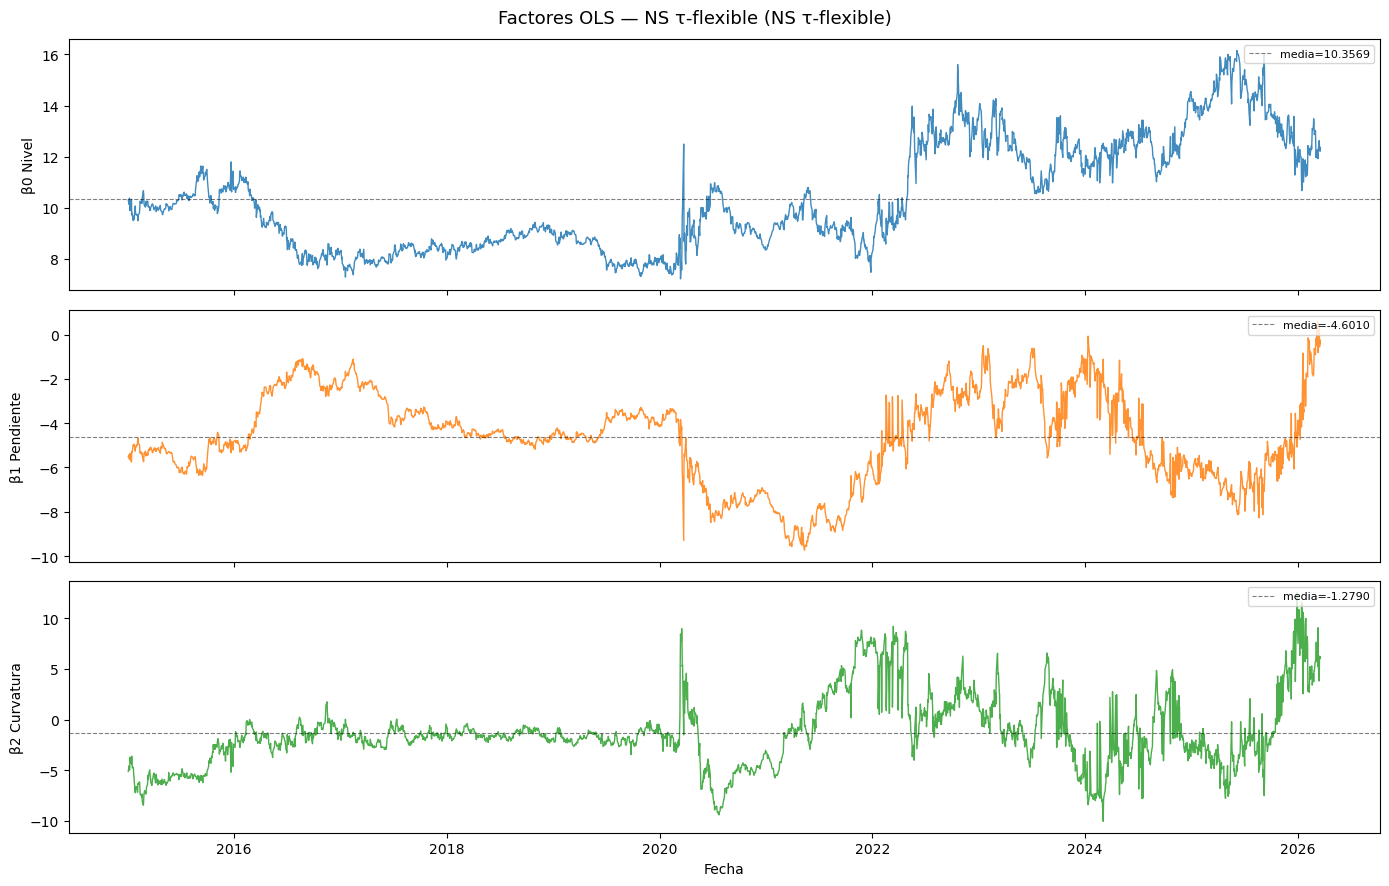

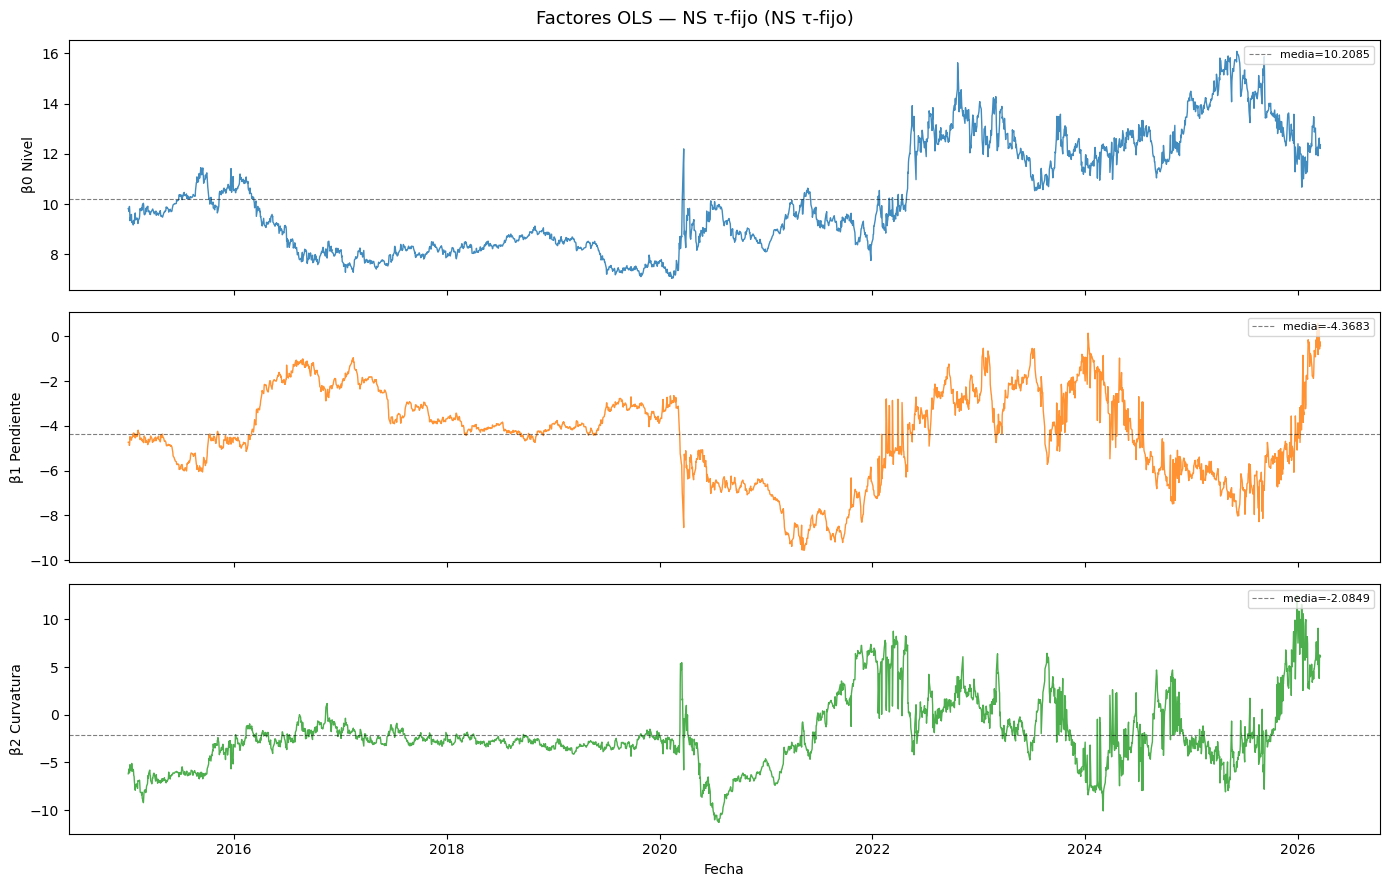

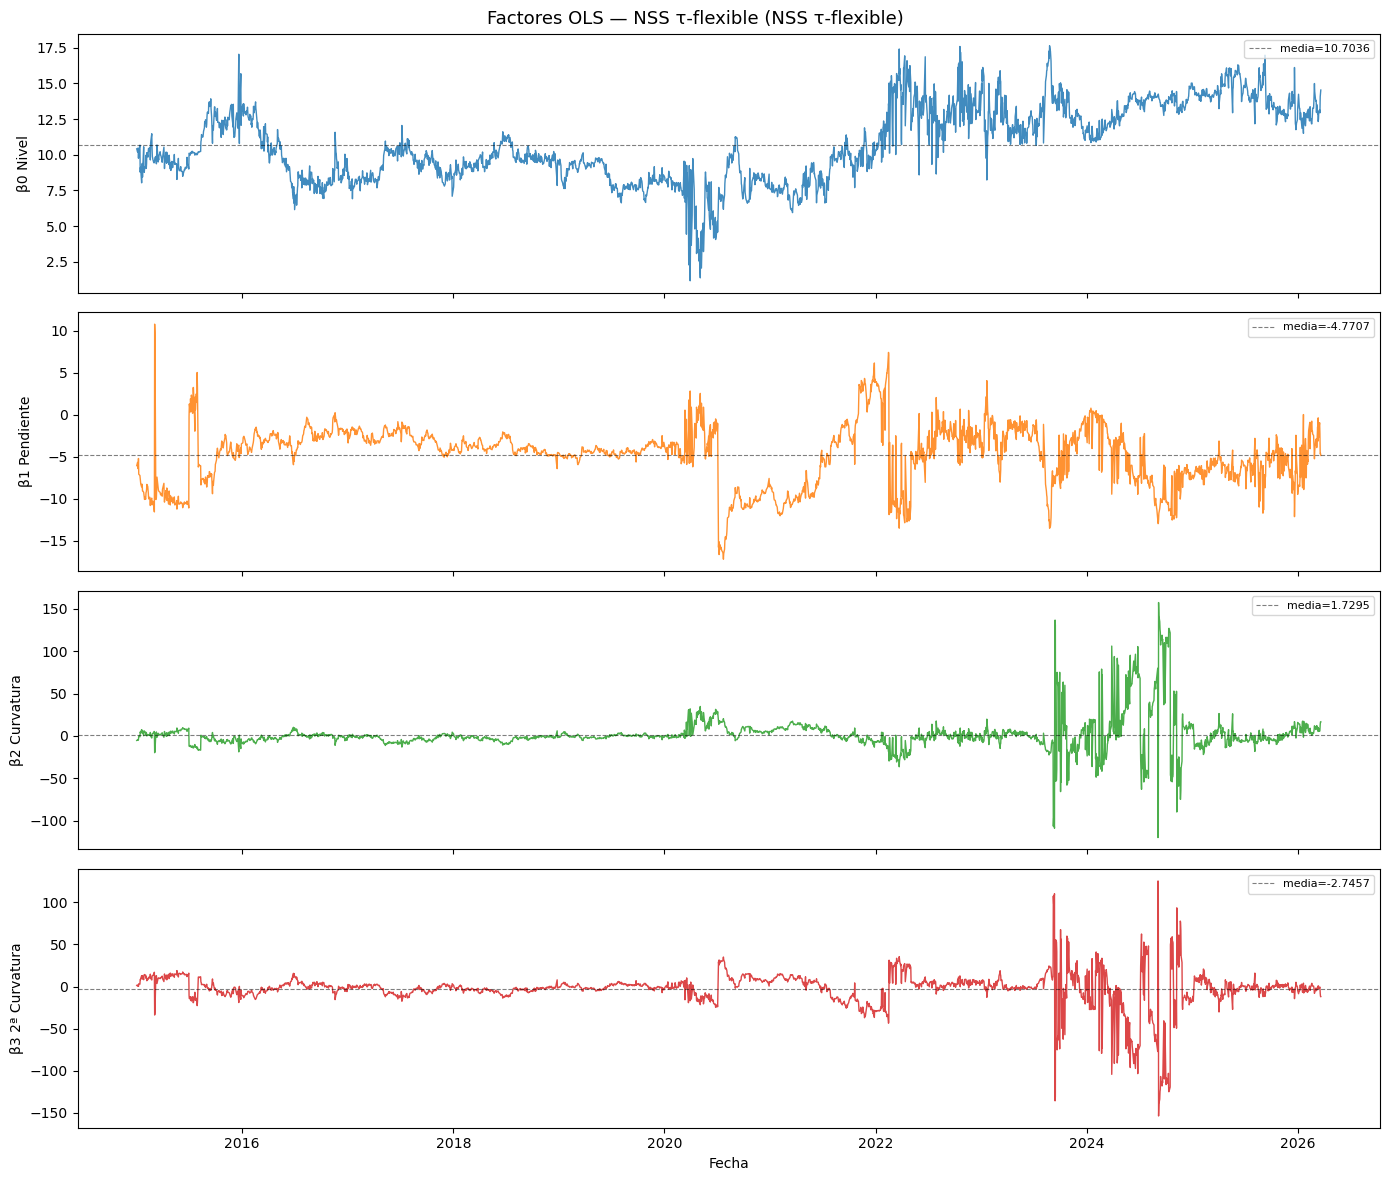

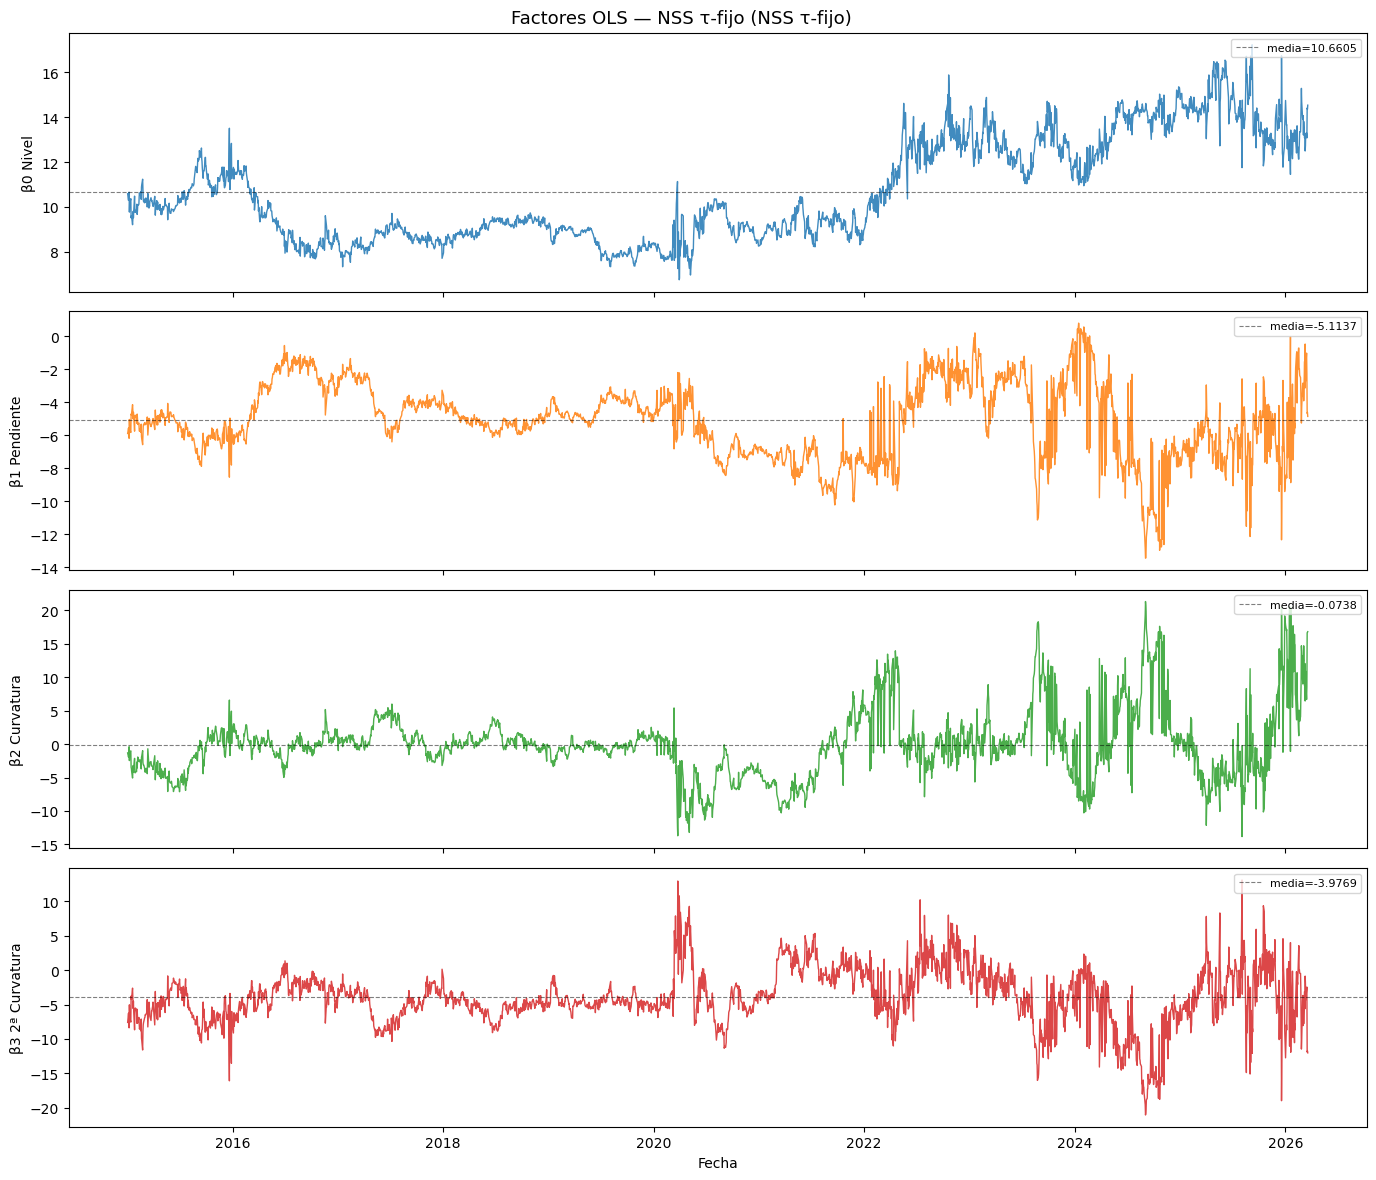

In [18]:
## CELDA 10: Análisis post-ajuste — Factores latentes $\boldsymbol{\beta}_t$
"""
Evolución temporal de los parámetros $\beta_0$ (nivel), $\beta_1$ (pendiente),
$\beta_2$ (curvatura) y $\beta_3$ (2ª curvatura para NSS).
"""

def plot_factores_ols(res, titulo_extra=''):
    """Grafica la evolución temporal de los betas estimados por OLS."""
    model  = res['model']
    mode   = res['tau_mode']
    dates  = res['dates']
    beta   = res['beta']
    k      = beta.shape[1]

    nombres = (['β0 Nivel', 'β1 Pendiente', 'β2 Curvatura']
               + (['β3 2ª Curvatura'] if k == 4 else []))

    fig, axes = plt.subplots(k, 1, figsize=(14, 3.0*k), sharex=True)
    if k == 1: axes = [axes]

    for i, (ax, nom, col) in enumerate(zip(axes, nombres, COLORES_FACTOR)):
        ax.plot(dates, beta[:, i], color=col, lw=1.0, alpha=0.85)
        ax.axhline(beta[:, i].mean(), color='k', lw=0.8, ls='--', alpha=0.5,
                   label=f'media={beta[:, i].mean():.4f}')
        ax.set_ylabel(nom, fontsize=10)
        ax.legend(fontsize=8, loc='upper right')
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

    axes[-1].set_xlabel('Fecha')
    fig.suptitle(f'Factores OLS — {model} τ-{mode}{titulo_extra}', fontsize=13)
    plt.tight_layout(); plt.show()


plot_factores_ols(res_ns_flex,  ' (NS τ-flexible)')
plot_factores_ols(res_ns_fijo,  ' (NS τ-fijo)')
plot_factores_ols(res_nss_flex, ' (NSS τ-flexible)')
plot_factores_ols(res_nss_fijo, ' (NSS τ-fijo)')


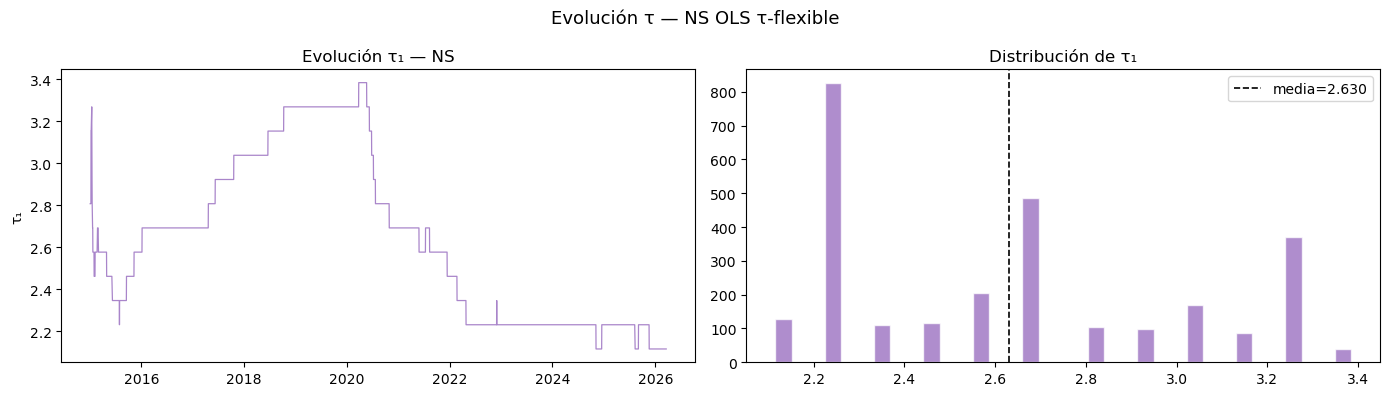

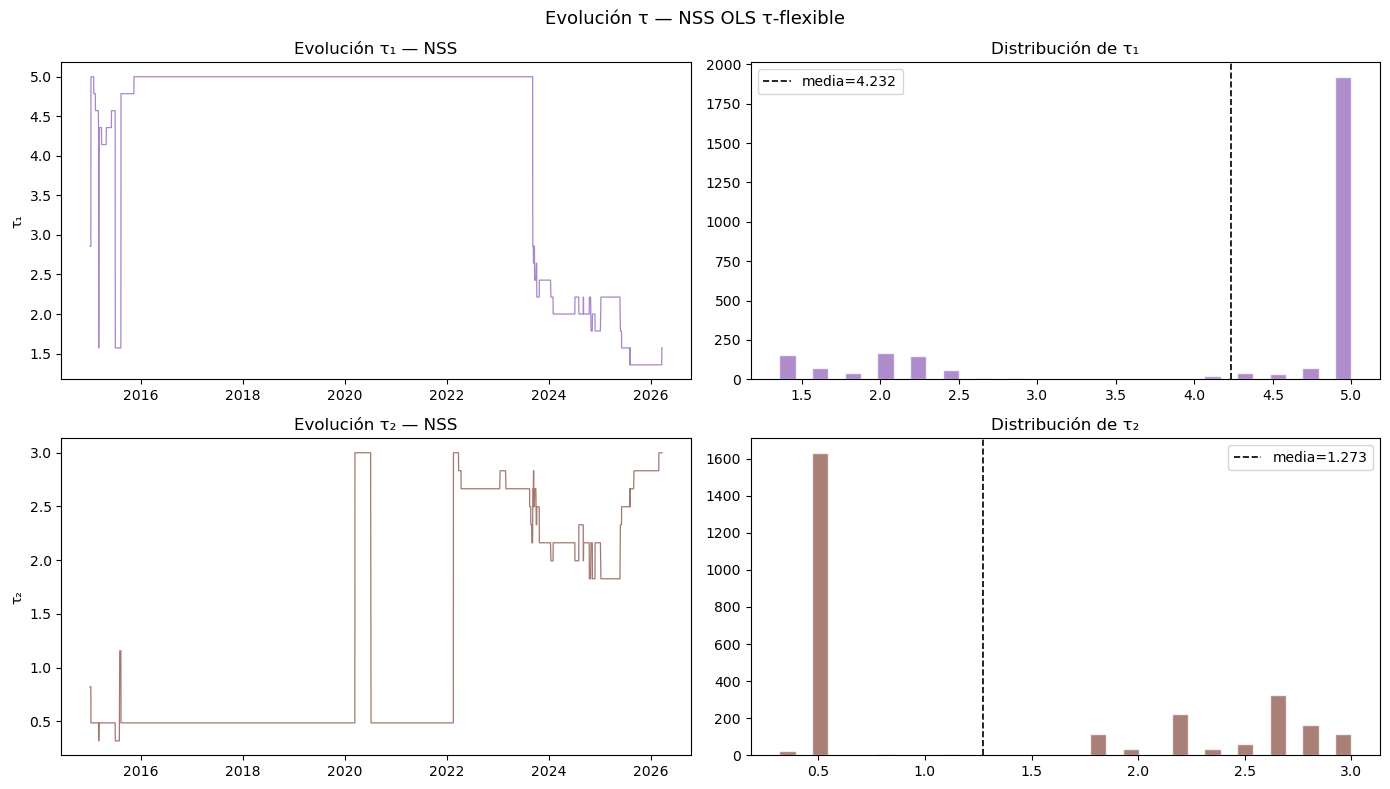

In [19]:

# ─── CELL 12: Tau evolution ───────────────────────────────────────────────────

## CELDA 11: Análisis post-ajuste — Evolución de $\\tau_t$ (modo flexible)
"""
$\\tau_t$ captura cambios estructurales en la curvatura de la curva a lo largo del tiempo.
"""

def plot_tau_evolution_ols(res):
    """"Muestra la evolución de tau_t para el modo flexible."""
    if res['tau_mode'] != 'flexible':
        print(f"[{res['model']}] tau_mode='{res['tau_mode']}' — tau es constante, no hay evolución que graficar.")
        return

    model  = res['model']
    dates  = res['dates']
    tau1_t = res['tau1_t']
    tau2_t = res['tau2_t']
    n_tau  = 1 if model == 'NS' else 2
    taus   = [tau1_t] if model == 'NS' else [tau1_t, tau2_t]
    lbls   = ['τ₁']   if model == 'NS' else ['τ₁', 'τ₂']

    fig, axes = plt.subplots(n_tau, 2, figsize=(14, 4*n_tau))
    if n_tau == 1: axes = axes[np.newaxis, :]

    for row, (tau_t, lbl, col) in enumerate(zip(taus, lbls, COLORES_TAU)):
        ax1, ax2 = axes[row]
        ax1.plot(dates, tau_t, color=col, lw=0.9, alpha=0.8)
        ax1.set_title(f'Evolución {lbl} — {model}'); ax1.set_ylabel(lbl)
        ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

        ax2.hist(tau_t[~np.isnan(tau_t)], bins=35, color=col, alpha=0.75, edgecolor='white')
        ax2.axvline(np.nanmean(tau_t), color='k', lw=1.2, ls='--',
                    label=f'media={np.nanmean(tau_t):.3f}')
        ax2.set_title(f'Distribución de {lbl}'); ax2.legend()

    fig.suptitle(f'Evolución τ — {model} OLS τ-flexible', fontsize=13)
    plt.tight_layout(); plt.show()


plot_tau_evolution_ols(res_ns_flex)
plot_tau_evolution_ols(res_nss_flex)





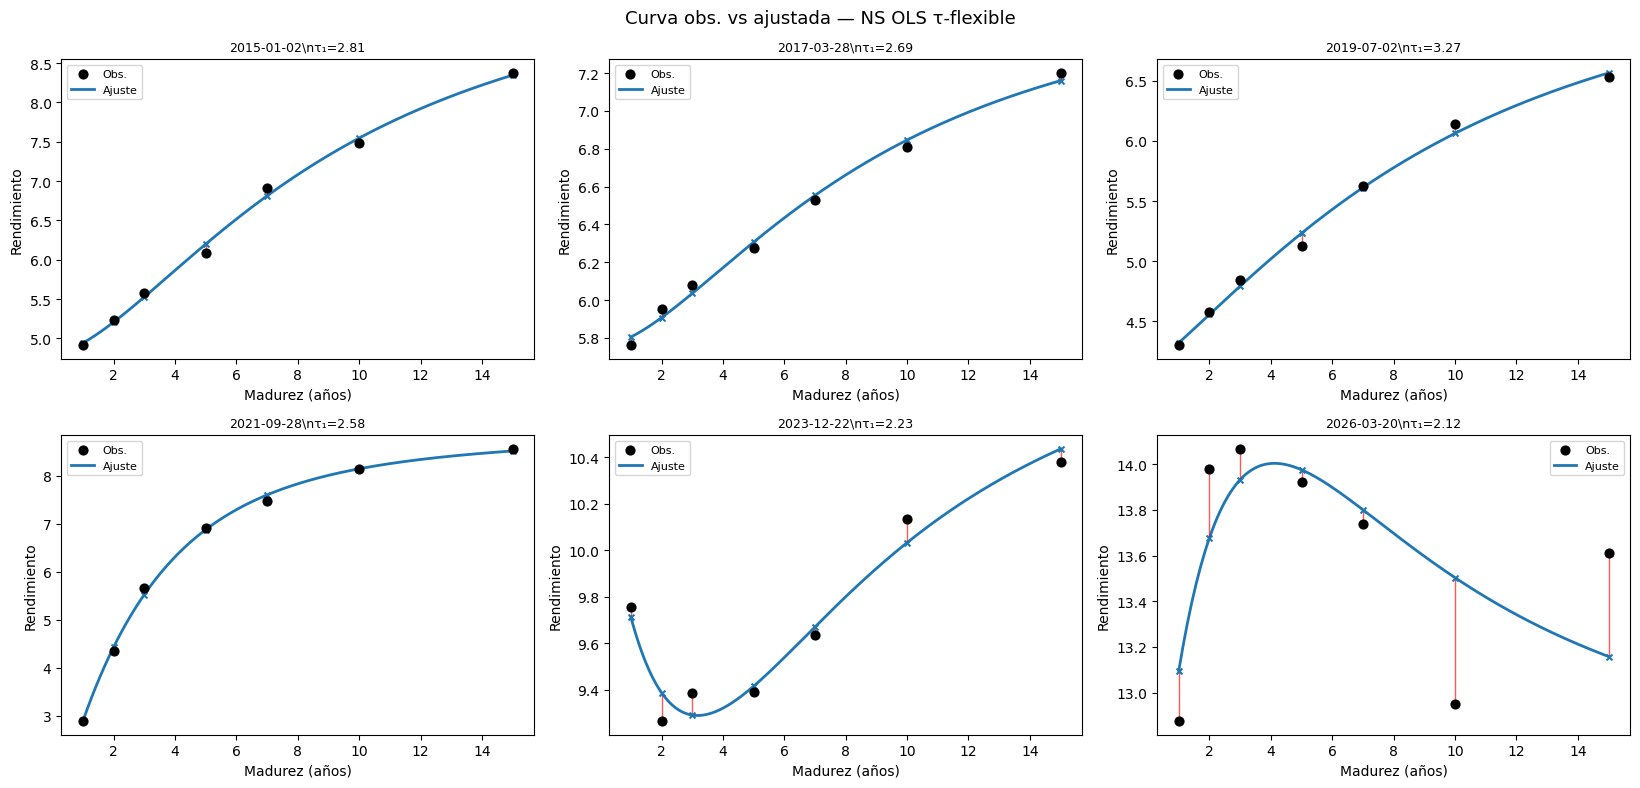

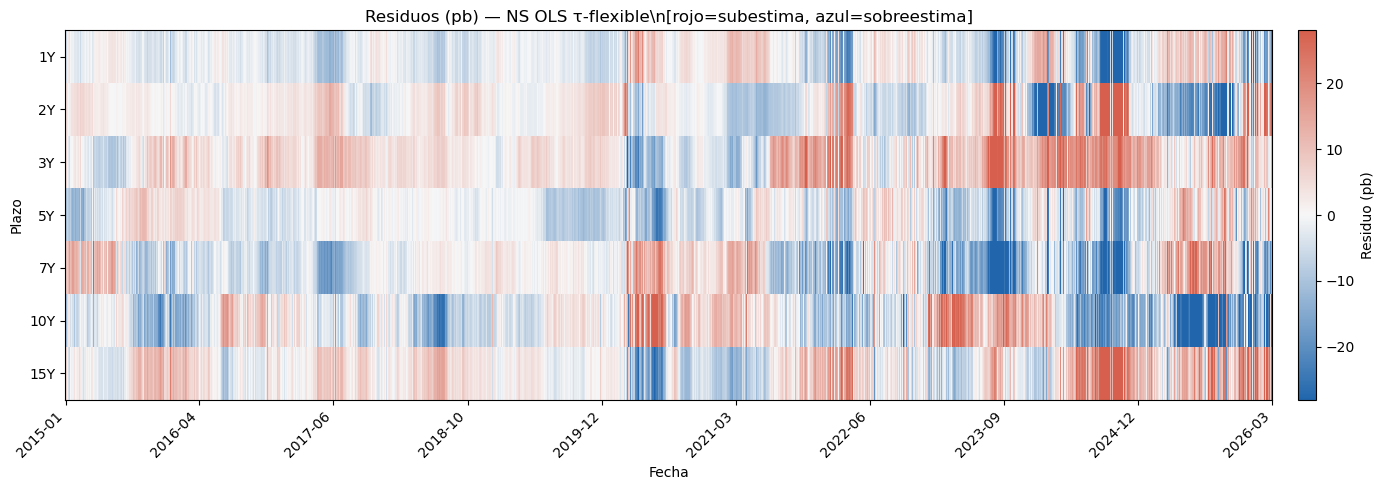

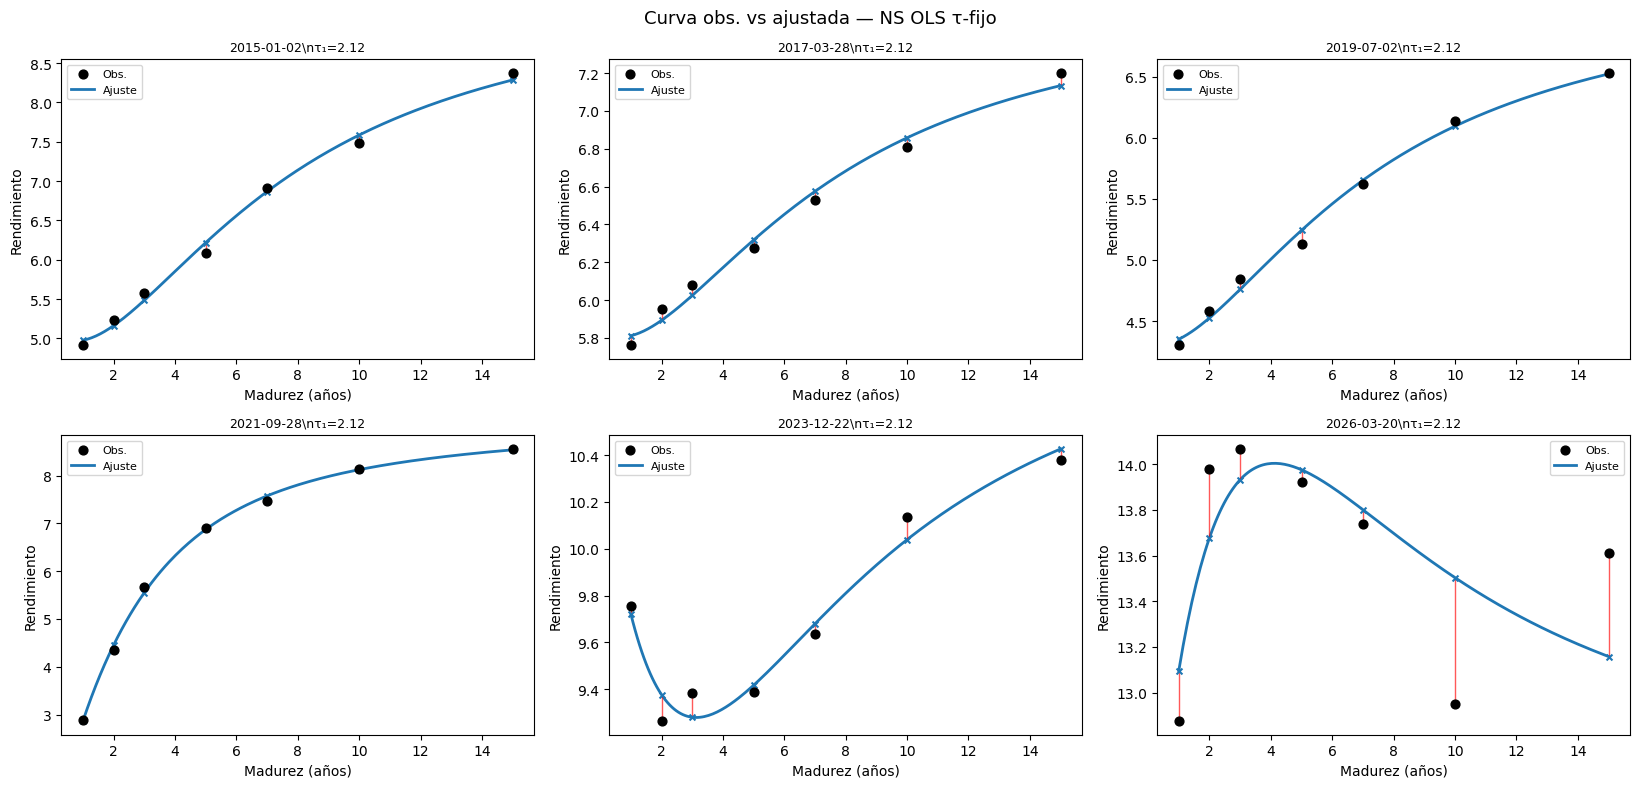

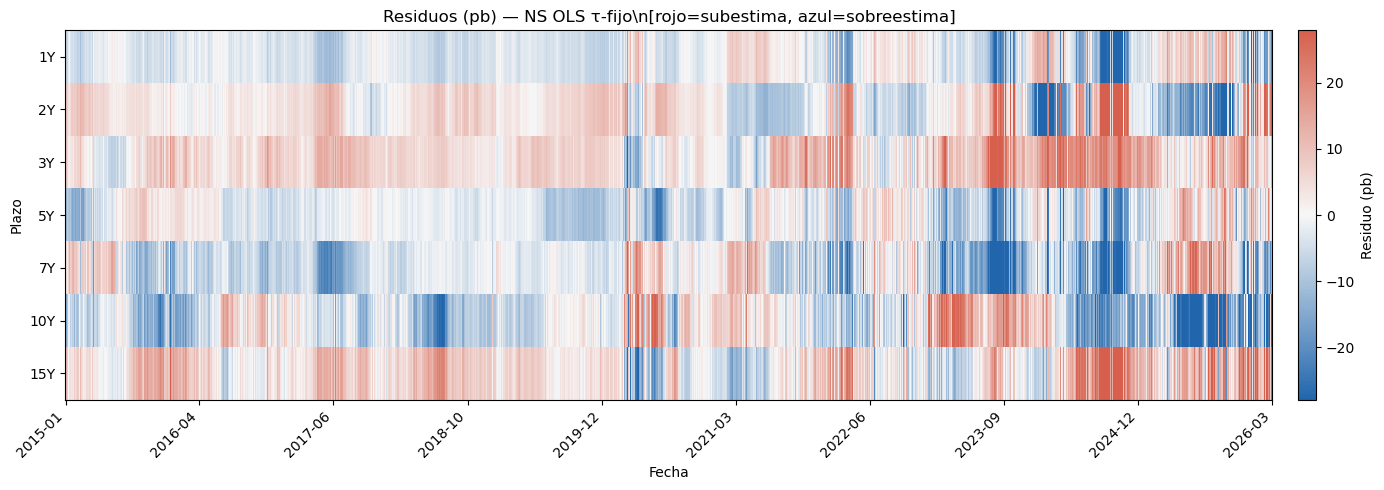

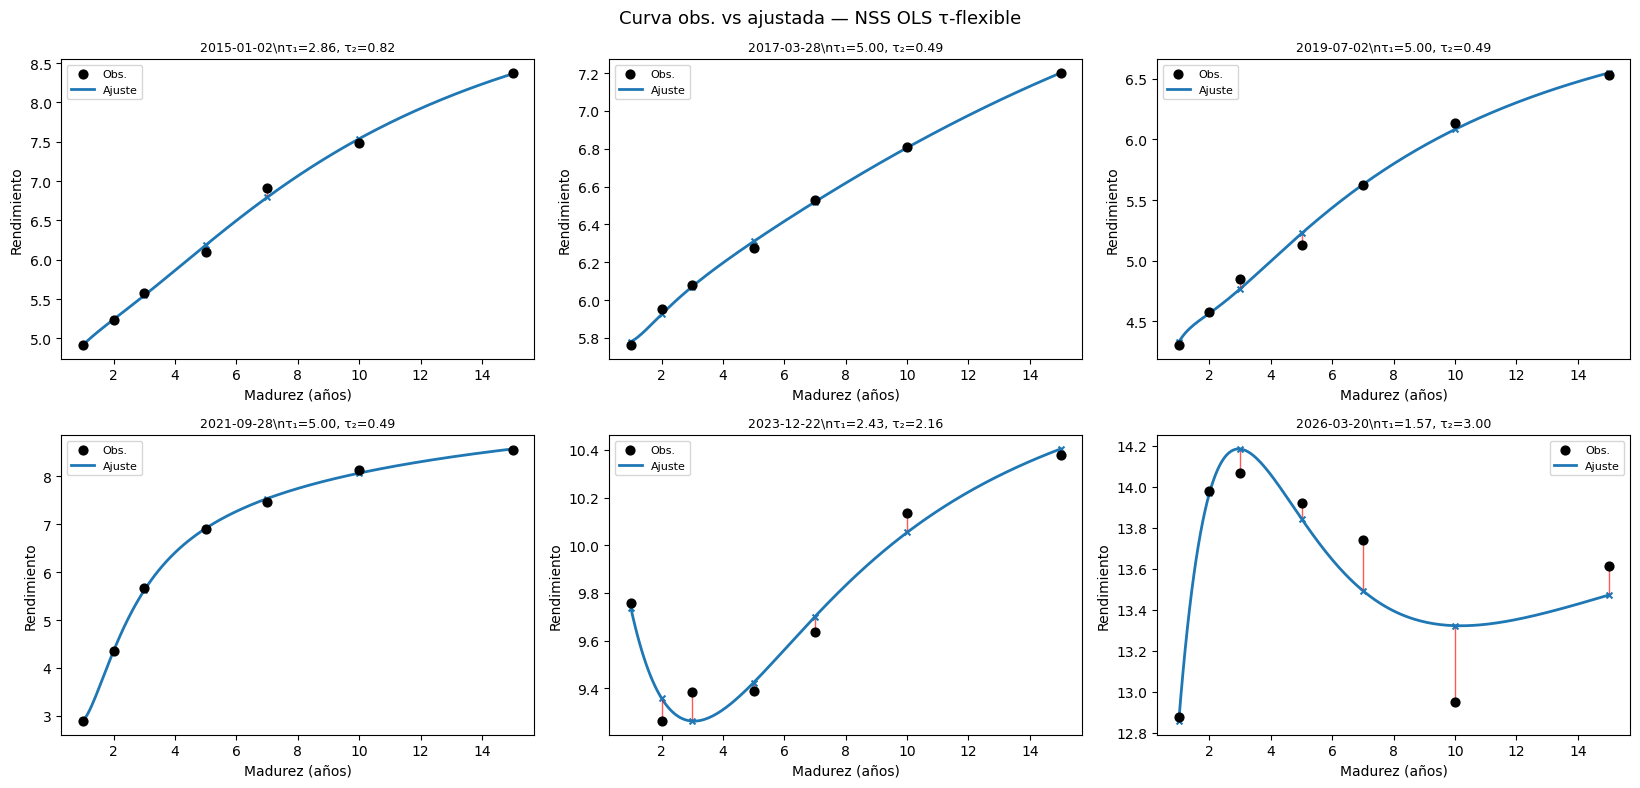

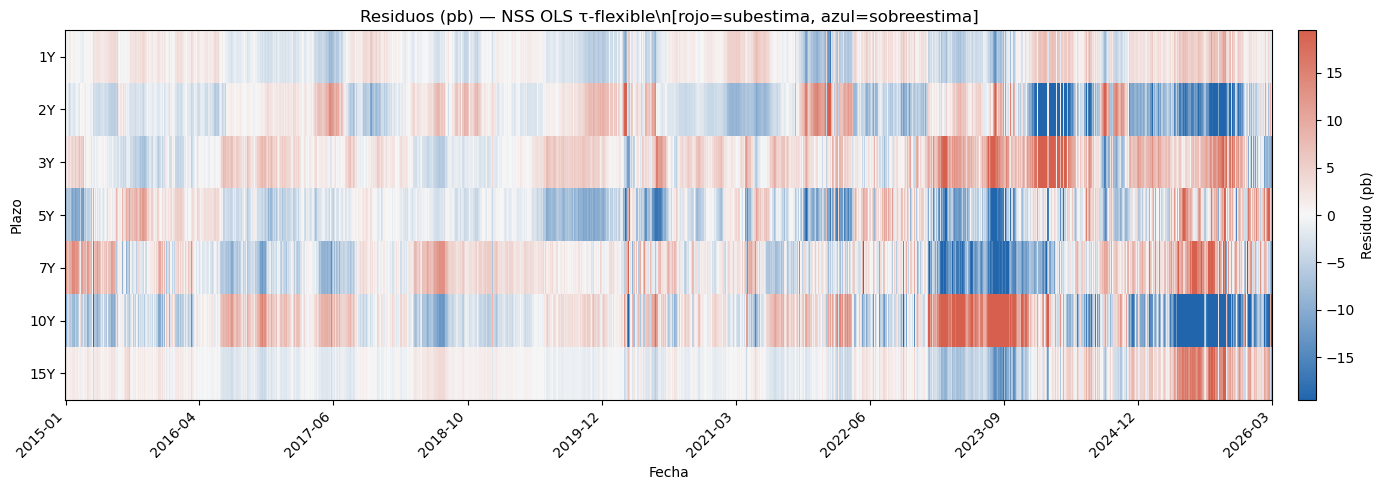

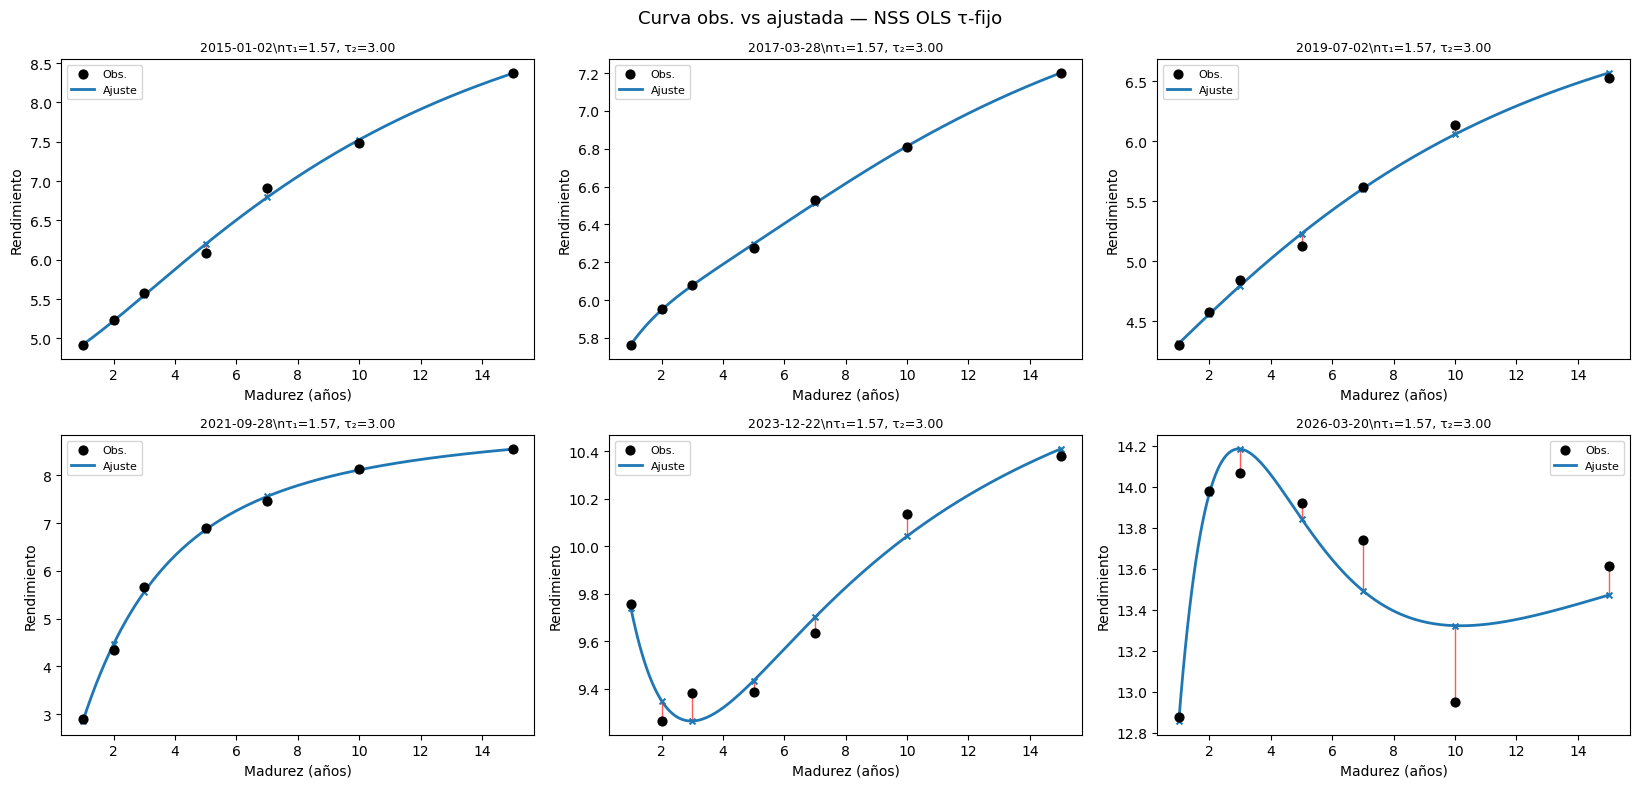

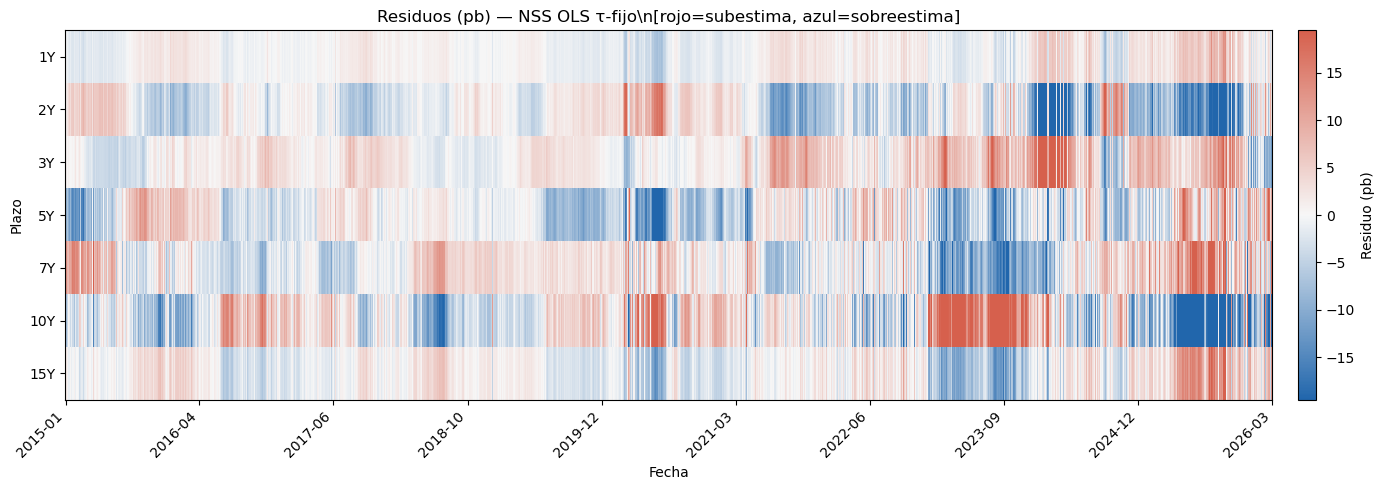

In [22]:
# ─── CELL 13: Fitted curves & heatmap ─────────────────────────────────────────

def plot_curvas_ajustadas_ols(res, n_fechas=6):
    """Curva ajustada vs observada para n_fechas seleccionadas."""
    model  = res['model']
    mode   = res['tau_mode']
    dates  = res['dates']
    yields = res['yields']
    mats   = res['maturities']
    beta   = res['beta']
    tau1_t = res['tau1_t']
    tau2_t = res['tau2_t']
    T      = len(dates)

    idx_sel = np.unique(np.linspace(0, T-1, n_fechas, dtype=int))
    m_fine  = np.linspace(mats.min(), mats.max(), 200)
    cols    = min(3, n_fechas)
    rows    = (n_fechas + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(5.5*cols, 4.0*rows))
    axes = np.array(axes).flatten()

    for ax, idx in zip(axes[:n_fechas], idx_sel):
        tau1 = tau1_t[idx]
        tau2 = tau2_t[idx] if (model == 'NSS' and not np.isnan(tau2_t[idx])) else None
        H_fine = get_loadings(m_fine, tau1, tau2, model)
        curve  = H_fine @ beta[idx]
        H_disc = res['H_arr'][idx]
        fit_d  = H_disc @ beta[idx]

        ax.scatter(mats, yields[idx], color='k', s=40, zorder=5, label='Obs.')
        ax.plot(m_fine, curve, color='#1f77b4', lw=2.0, label='Ajuste')
        ax.scatter(mats, fit_d, color='#1f77b4', s=18, marker='x', zorder=4)
        for mi, fi, oi in zip(mats, fit_d, yields[idx]):
            ax.plot([mi, mi], [fi, oi], color='red', lw=1.0, alpha=0.65)

        tau_str = f'τ₁={tau1:.2f}' if model == 'NS' else f'τ₁={tau1:.2f}, τ₂={tau2:.2f}'
        ax.set_title(f'{str(dates[idx])[:10]}\\n{tau_str}', fontsize=9)
        ax.set_xlabel('Madurez (años)'); ax.set_ylabel('Rendimiento')
        ax.legend(fontsize=8)

    for ax in axes[n_fechas:]:
        ax.set_visible(False)
    fig.suptitle(f'Curva obs. vs ajustada — {model} OLS τ-{mode}', fontsize=13)
    plt.tight_layout(); plt.show()


def plot_heatmap_residuos_ols(res):
    """Heatmap de residuos en el tiempo."""
    model = res['model']; mode = res['tau_mode']
    dates = res['dates']; resid = res['residuals'] * 100; mats = res['maturities']
    T     = len(dates)

    fig, ax = plt.subplots(figsize=(14, 5))
    vmax = np.percentile(np.abs(resid), 97)
    norm = TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)
    cmap = LinearSegmentedColormap.from_list('bwr_soft', ['#2166ac','#f7f7f7','#d6604d'], N=256)
    im   = ax.imshow(resid.T, aspect='auto', cmap=cmap, norm=norm, interpolation='nearest')

    n_t     = min(10, T//40+1)
    t_ticks = np.linspace(0, T-1, n_t, dtype=int)
    ax.set_xticks(t_ticks)
    ax.set_xticklabels([str(dates[i])[:7] for i in t_ticks], rotation=45, ha='right')
    ax.set_yticks(range(len(mats)))
    ax.set_yticklabels([f'{m:.0f}Y' for m in mats])
    ax.set_xlabel('Fecha'); ax.set_ylabel('Plazo')
    ax.set_title(f'Residuos (pb) — {model} OLS τ-{mode}\\n[rojo=subestima, azul=sobreestima]')
    plt.colorbar(im, ax=ax, fraction=0.025, pad=0.02, label='Residuo (pb)')
    plt.tight_layout(); plt.show()


for res in [res_ns_flex, res_ns_fijo, res_nss_flex, res_nss_fijo]:
    plot_curvas_ajustadas_ols(res, n_fechas=6)
    plot_heatmap_residuos_ols(res)


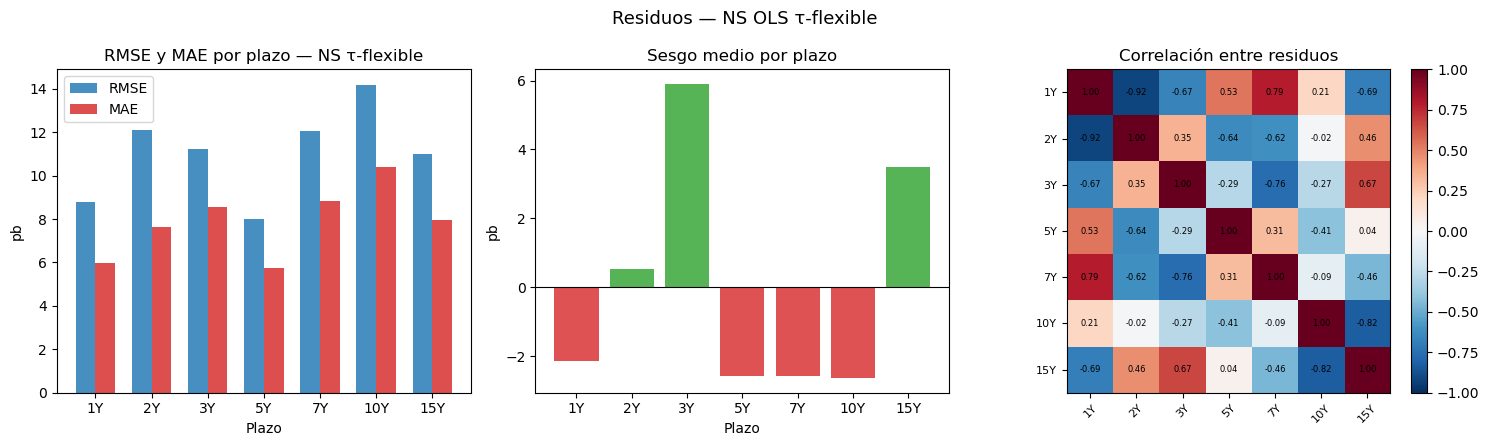

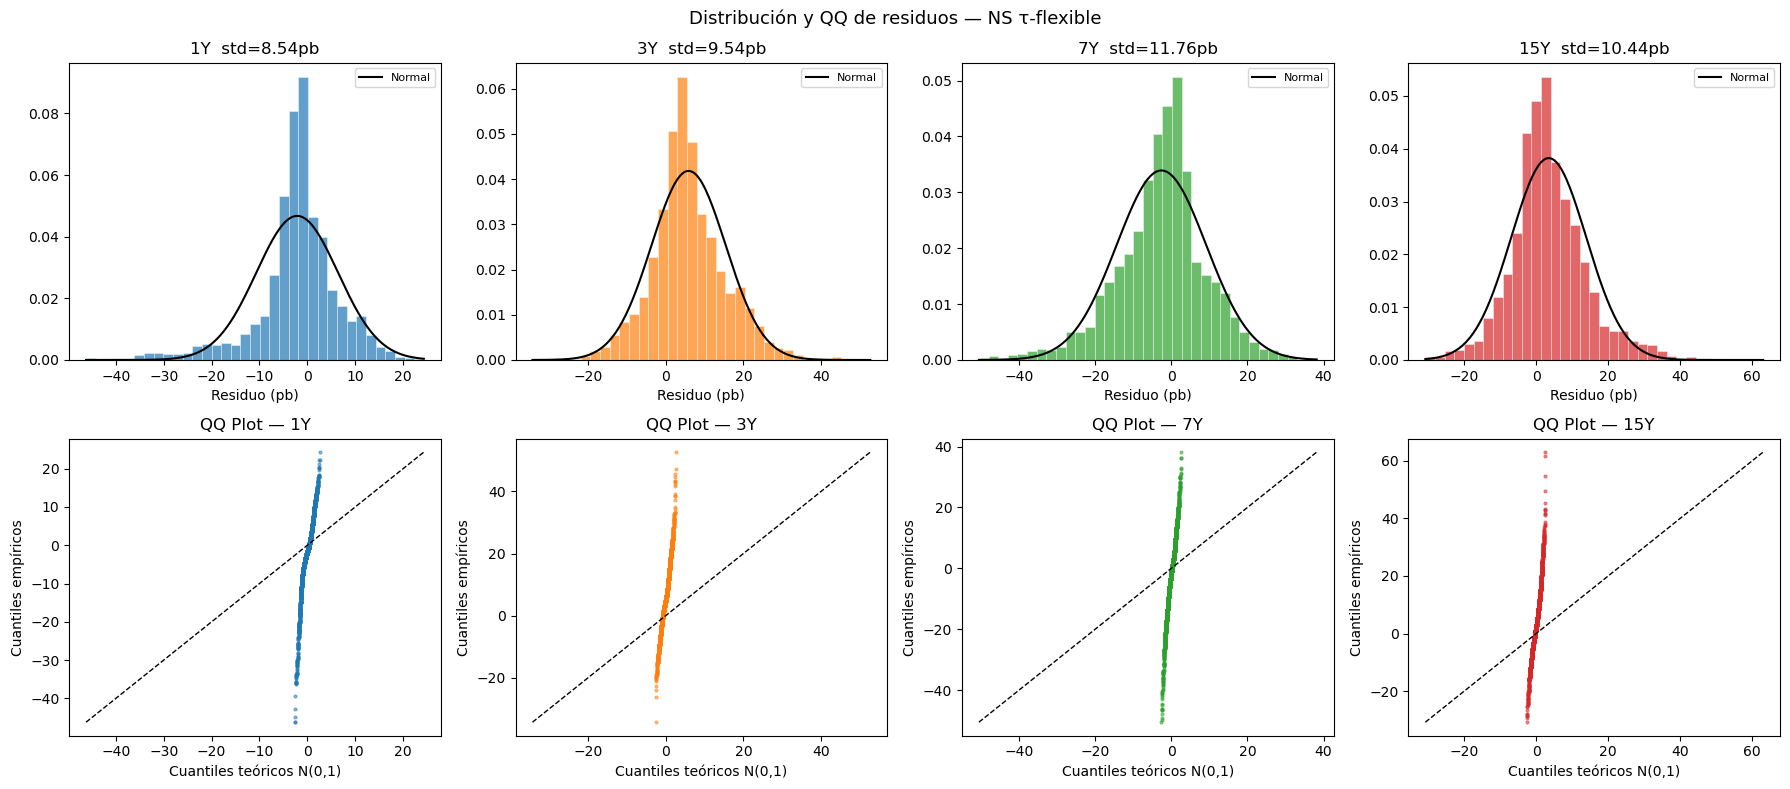

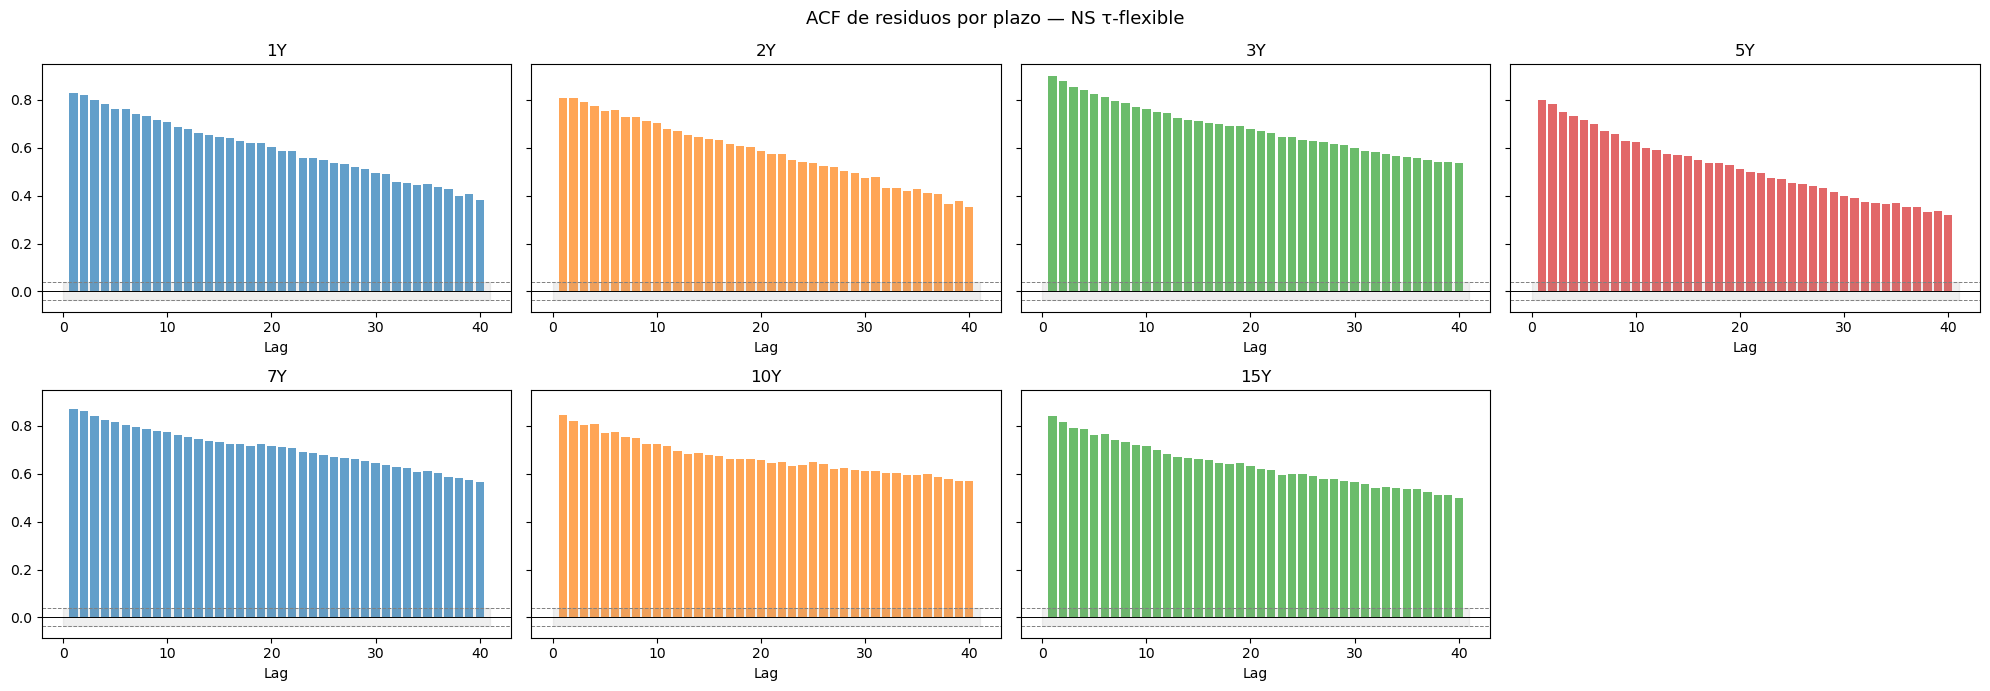

\n── Tests de residuos — NS OLS τ-flexible ──────────────────────────
  Plazo      RMSE     Sesgo   JB p-val   LB(10)p  Normal?  SerialCorr?
  ──────────────────────────────────────────────────────────────────────────
     1Y     8.799    -2.134     0.0000    0.0000  No      Sí
     2Y    12.111    +0.523     0.0000    0.0000  No      Sí
     3Y    11.217    +5.899     0.0000    0.0000  No      Sí
     5Y     7.979    -2.565     0.0000    0.0000  No      Sí
     7Y    12.043    -2.578     0.0000    0.0000  No      Sí
    10Y    14.184    -2.635     0.0000    0.0000  No      Sí
    15Y    11.004    +3.490     0.0000    0.0000  No      Sí


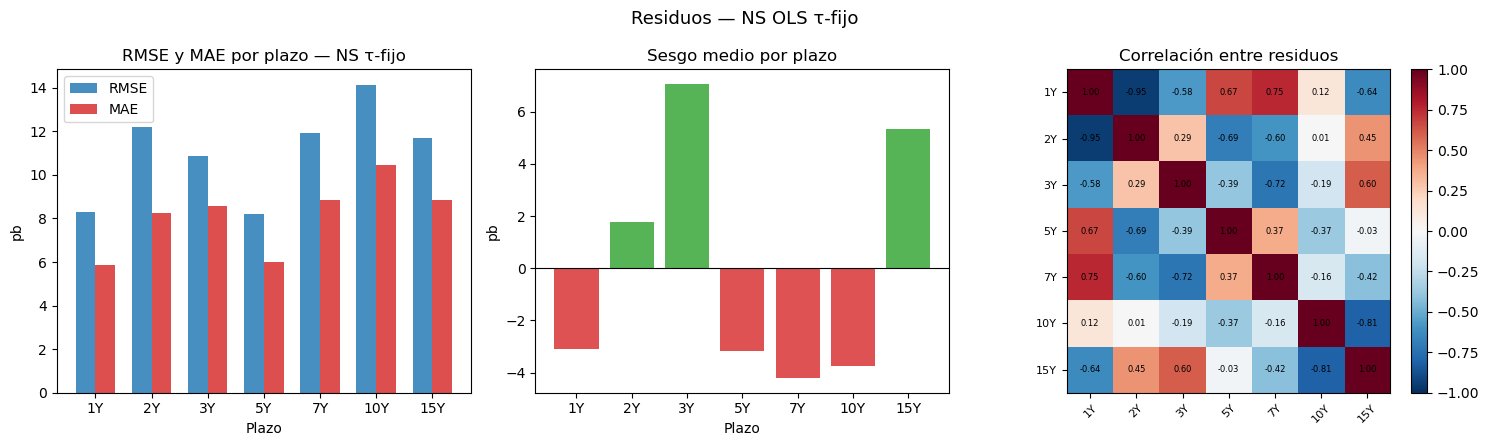

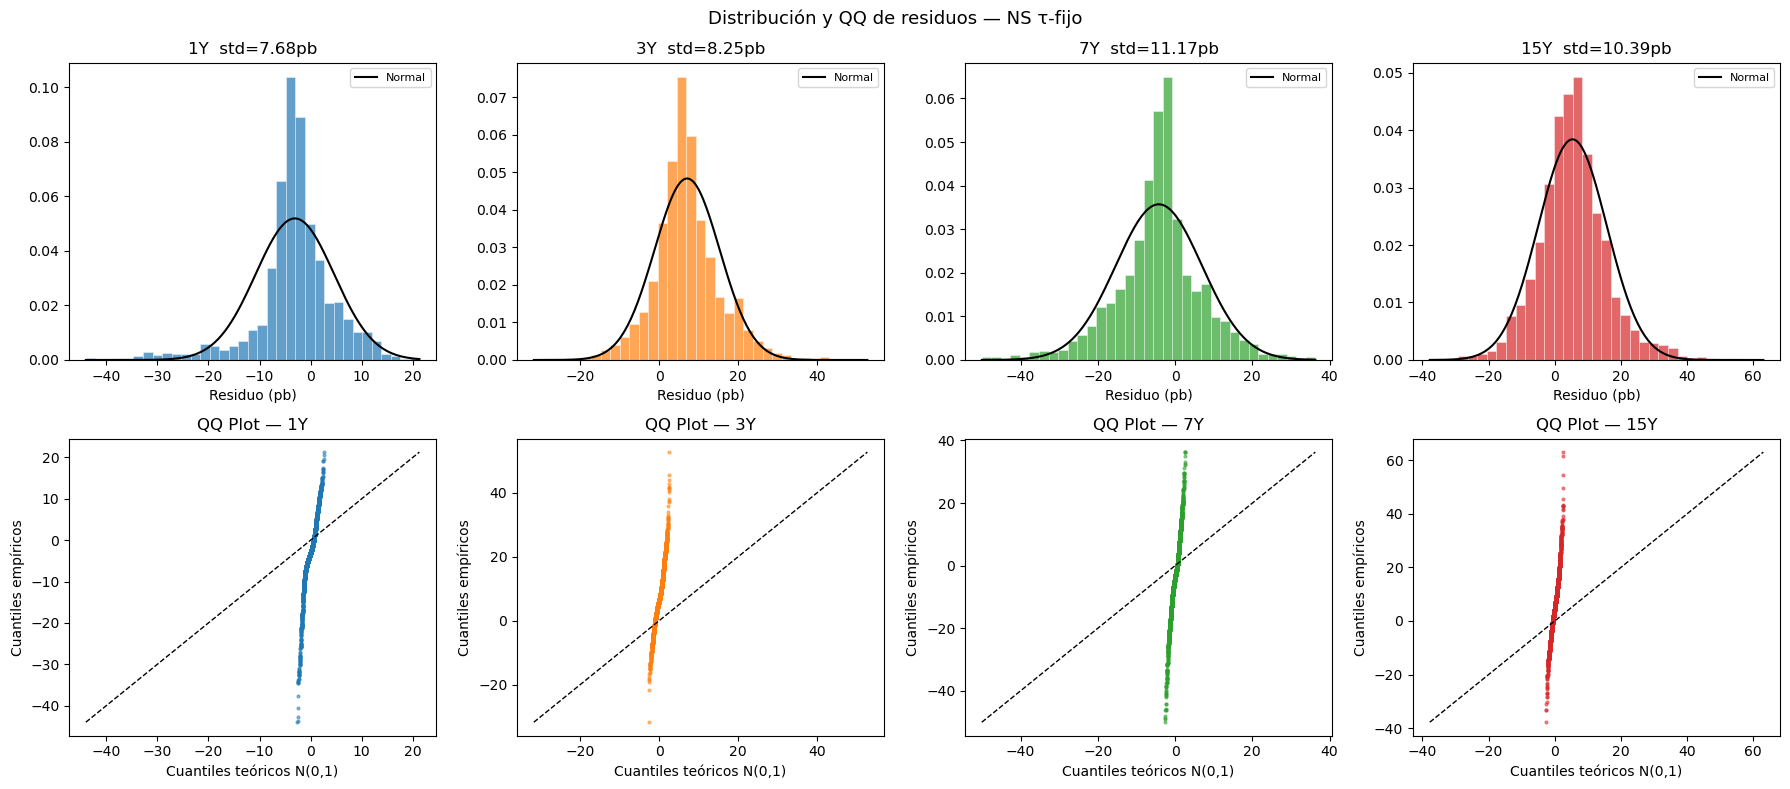

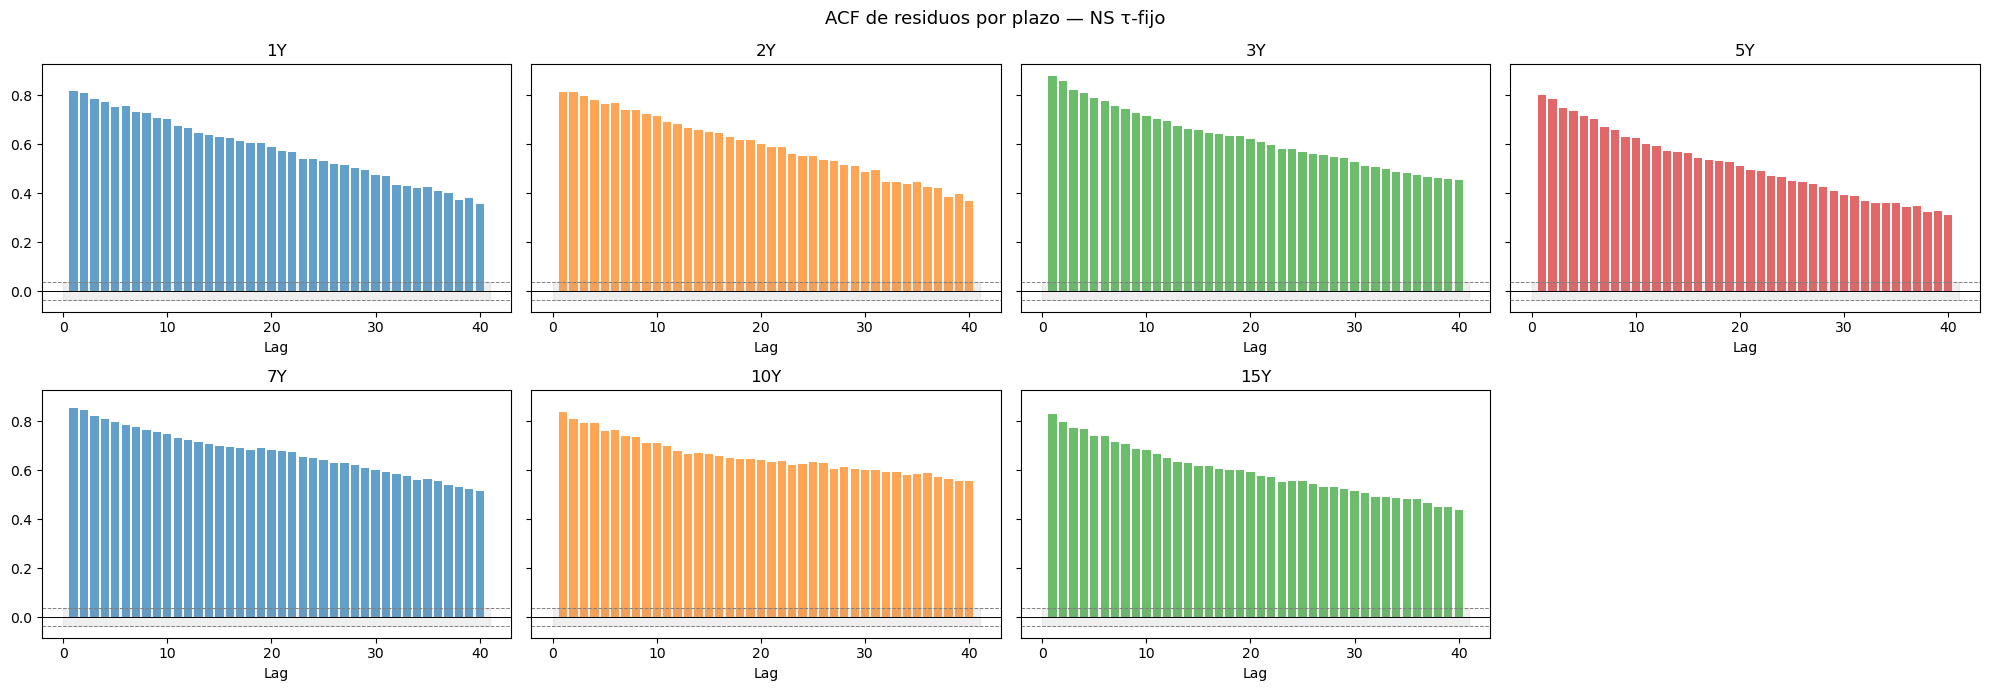

\n── Tests de residuos — NS OLS τ-fijo ──────────────────────────
  Plazo      RMSE     Sesgo   JB p-val   LB(10)p  Normal?  SerialCorr?
  ──────────────────────────────────────────────────────────────────────────
     1Y     8.276    -3.082     0.0000    0.0000  No      Sí
     2Y    12.183    +1.779     0.0000    0.0000  No      Sí
     3Y    10.860    +7.066     0.0000    0.0000  No      Sí
     5Y     8.207    -3.172     0.0000    0.0000  No      Sí
     7Y    11.936    -4.210     0.0000    0.0000  No      Sí
    10Y    14.140    -3.736     0.0000    0.0000  No      Sí
    15Y    11.690    +5.356     0.0000    0.0000  No      Sí


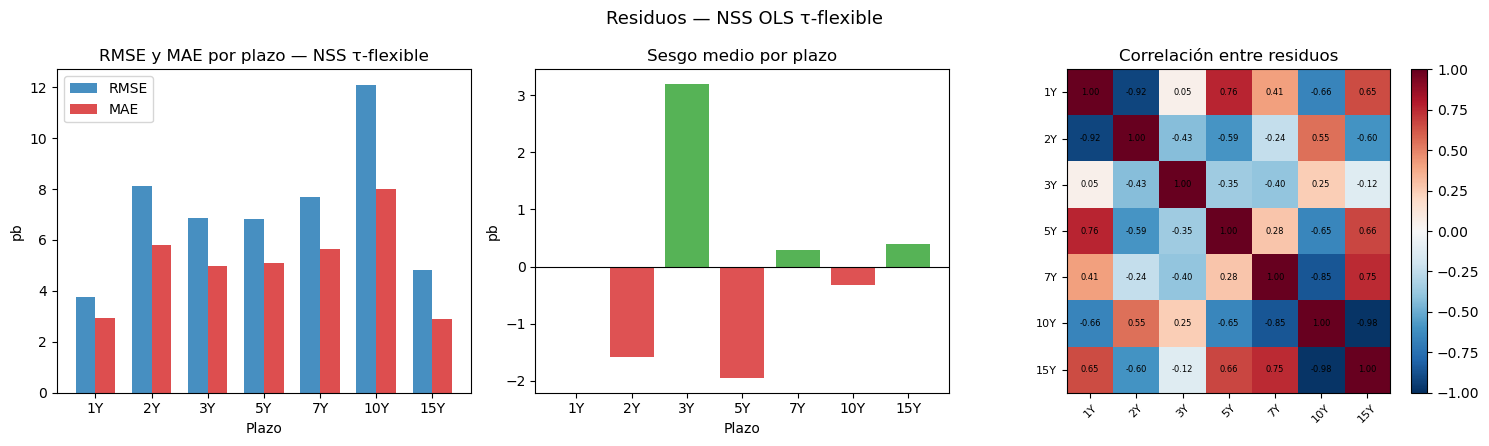

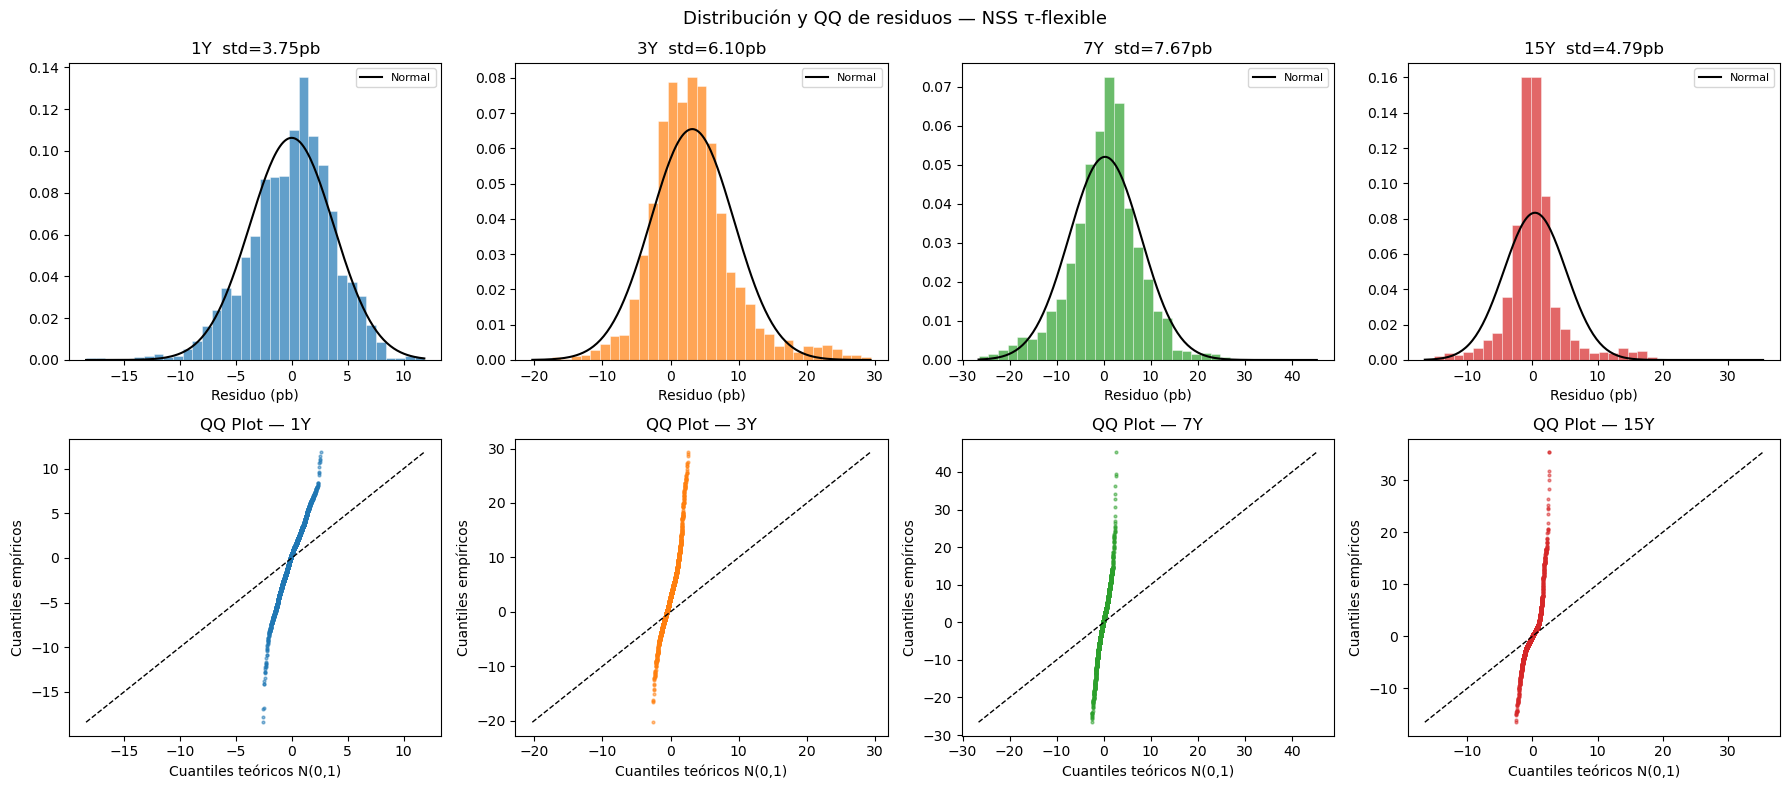

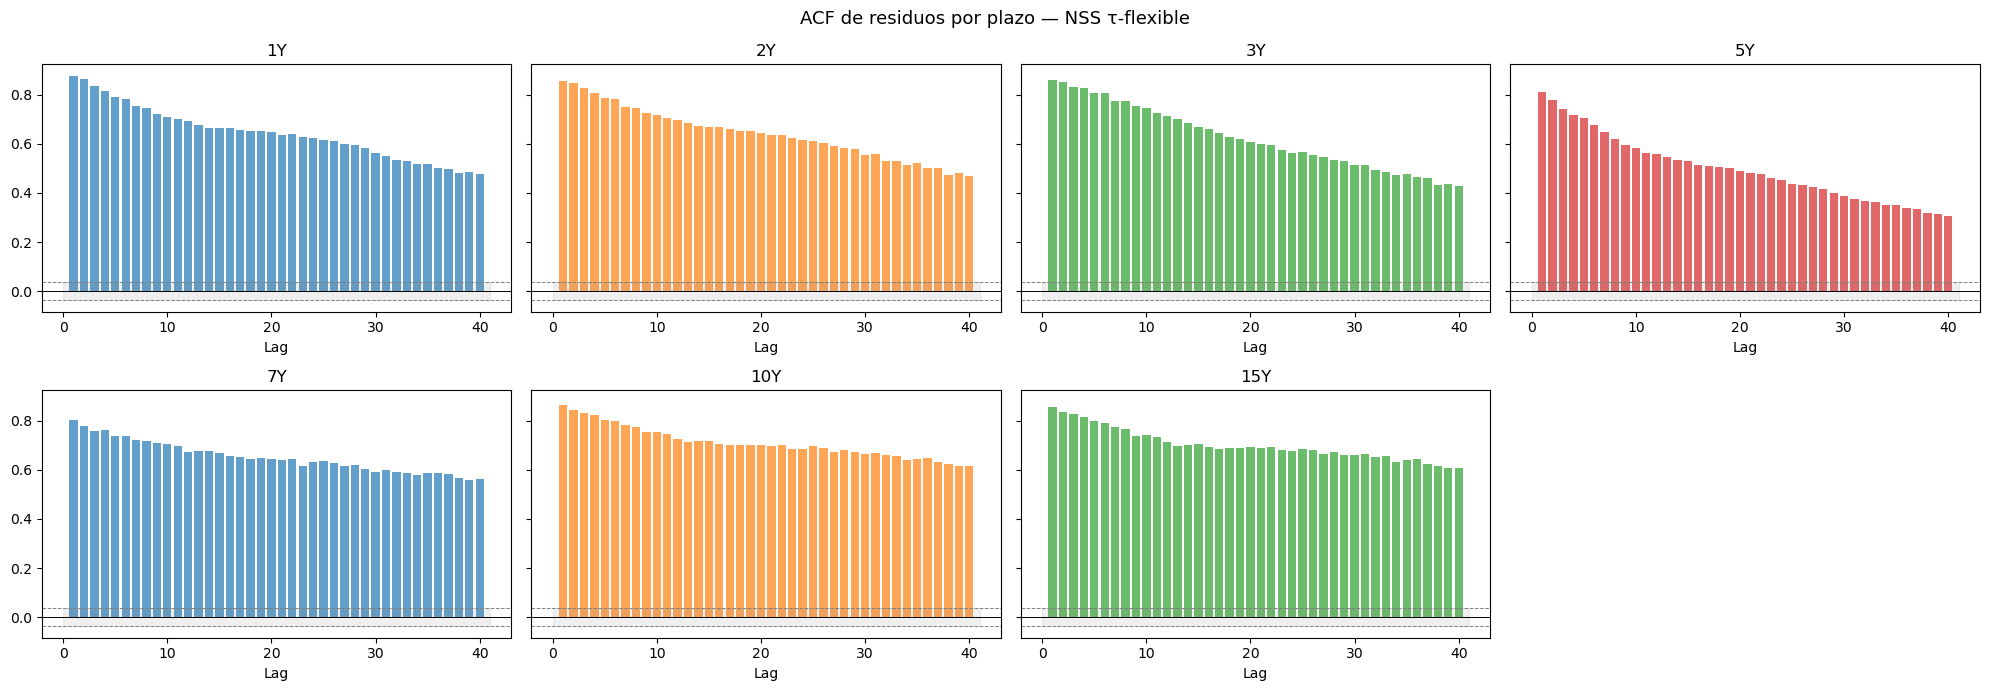

\n── Tests de residuos — NSS OLS τ-flexible ──────────────────────────
  Plazo      RMSE     Sesgo   JB p-val   LB(10)p  Normal?  SerialCorr?
  ──────────────────────────────────────────────────────────────────────────
     1Y     3.755    -0.005     0.0000    0.0000  No      Sí
     2Y     8.104    -1.584     0.0000    0.0000  No      Sí
     3Y     6.881    +3.194     0.0000    0.0000  No      Sí
     5Y     6.836    -1.951     0.0000    0.0000  No      Sí
     7Y     7.676    +0.291     0.0000    0.0000  No      Sí
    10Y    12.099    -0.331     0.0000    0.0000  No      Sí
    15Y     4.802    +0.386     0.0000    0.0000  No      Sí


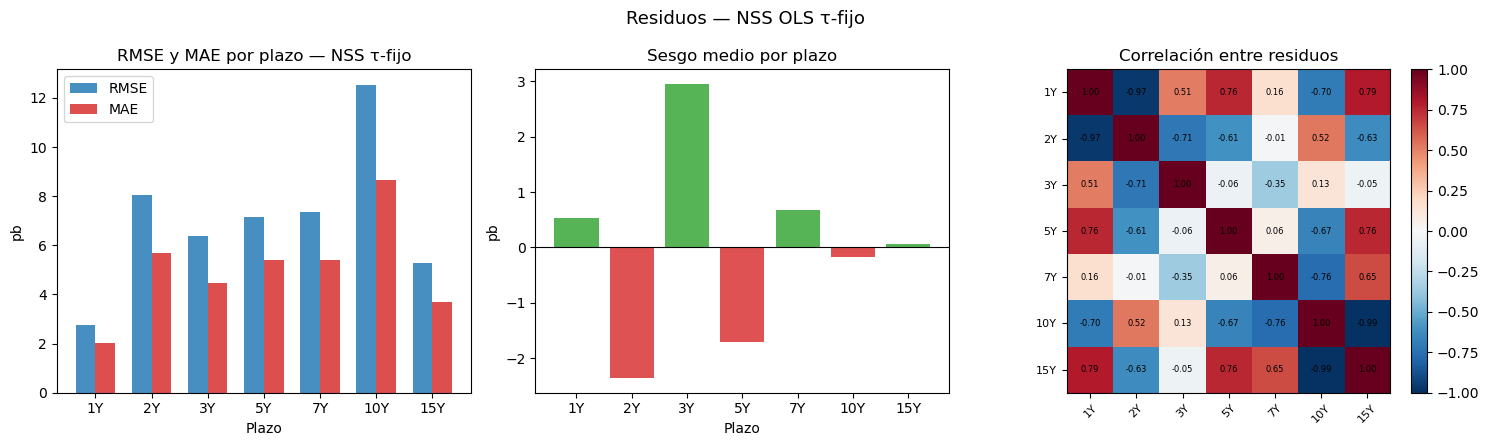

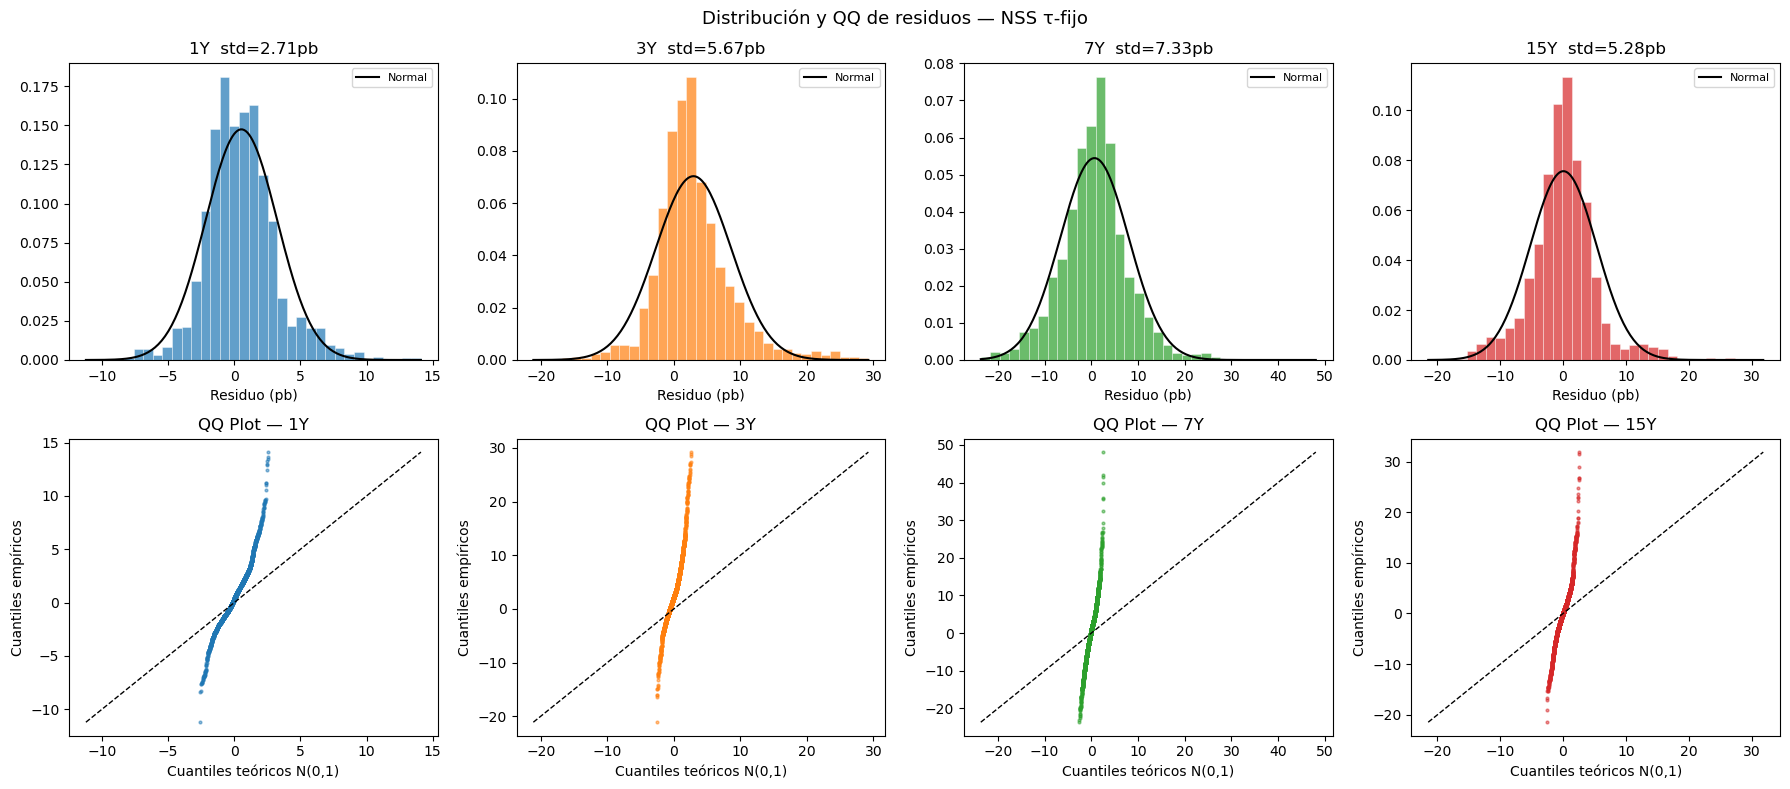

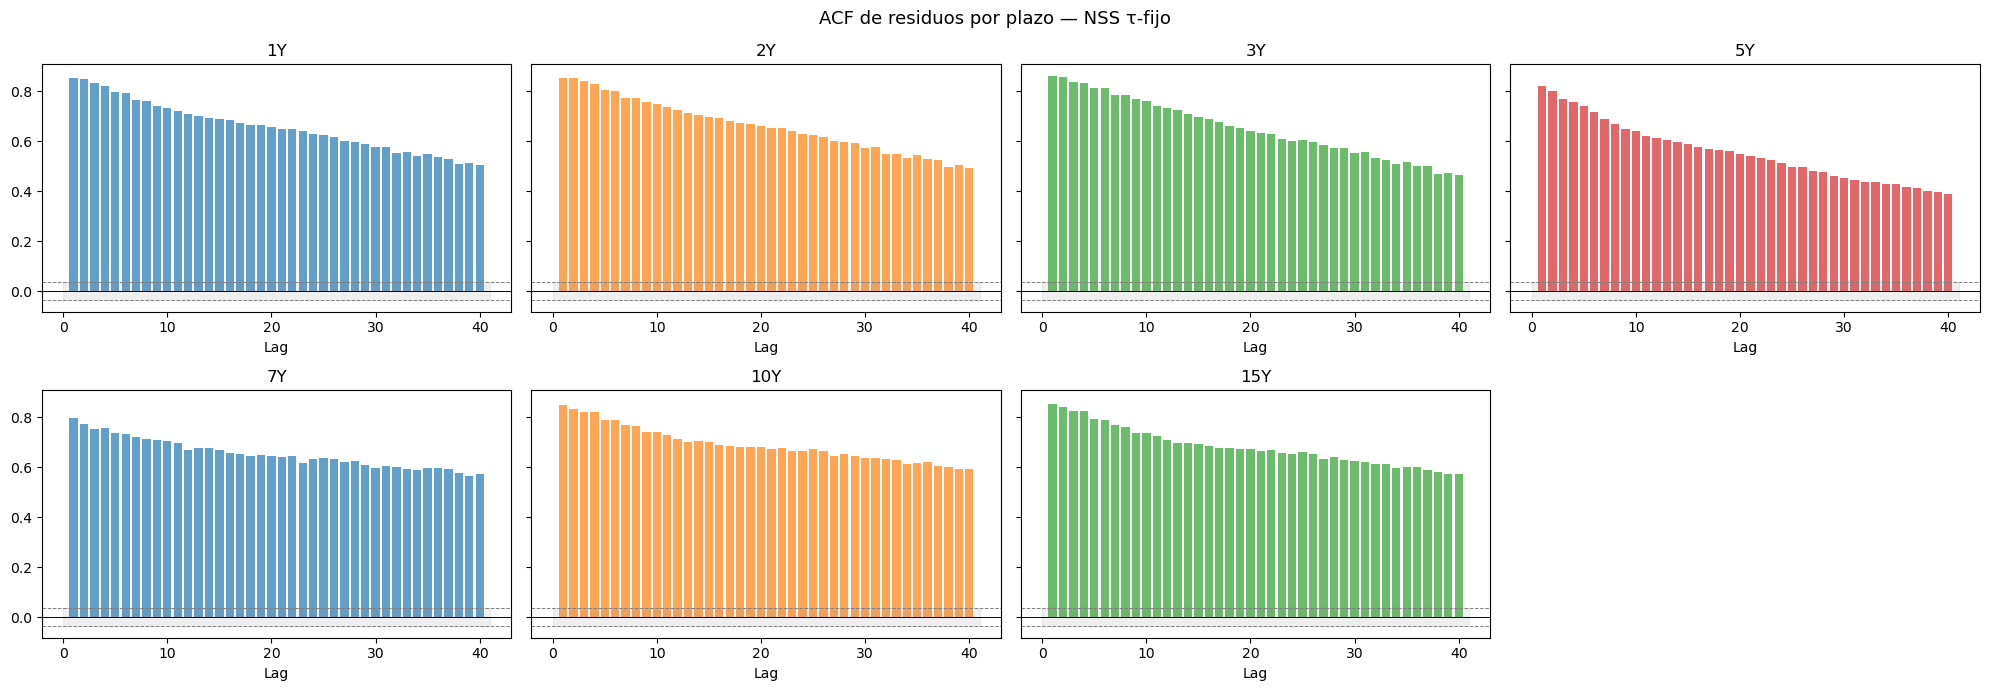

\n── Tests de residuos — NSS OLS τ-fijo ──────────────────────────
  Plazo      RMSE     Sesgo   JB p-val   LB(10)p  Normal?  SerialCorr?
  ──────────────────────────────────────────────────────────────────────────
     1Y     2.759    +0.539     0.0000    0.0000  No      Sí
     2Y     8.030    -2.353     0.0000    0.0000  No      Sí
     3Y     6.393    +2.946     0.0000    0.0000  No      Sí
     5Y     7.140    -1.704     0.0000    0.0000  No      Sí
     7Y     7.359    +0.680     0.0000    0.0000  No      Sí
    10Y    12.538    -0.167     0.0000    0.0000  No      Sí
    15Y     5.279    +0.059     0.0000    0.0000  No      Sí


In [23]:
# ─── CELL 14: Residual analysis (adapted from Kalman notebook) ────────────────

## CELDA 13: Análisis de residuos — RMSE, MAE, Sesgo, Correlación, Distribución, ACF
"""
Adaptación directa del análisis post-ajuste del notebook Kalman (`analisis_residuos`),
con entrada estandarizada compatible con cualquier método de ajuste.
"""

def analisis_residuos_ols(res):
    """
    Análisis completo de residuos de medición.
    Entrada: dict con 'model', 'tau_mode', 'dates', 'residuals', 'maturities'.
    Compatible con cualquier método de ajuste (OLS, Kalman, etc.).
    """
    model = res['model']; mode  = res['tau_mode']
    dates = res['dates']; resid = res['residuals']
    mats  = res['maturities']
    T, N  = resid.shape
    pb    = resid * 100

    rmse_m = np.sqrt(np.mean(resid**2, axis=0)) * 100
    mae_m  = np.mean(np.abs(resid),    axis=0)  * 100
    bias_m = resid.mean(axis=0)                 * 100

    # ── (1) RMSE, MAE, Sesgo y correlación cruzada ────────────────────────────
    fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
    x = np.arange(N); w = 0.35

    axes[0].bar(x-w/2, rmse_m, w, label='RMSE', color='#1f77b4', alpha=0.82)
    axes[0].bar(x+w/2, mae_m,  w, label='MAE',  color='#d62728', alpha=0.82)
    axes[0].set_xticks(x); axes[0].set_xticklabels([f'{m:.0f}Y' for m in mats])
    axes[0].set_xlabel('Plazo'); axes[0].set_ylabel('pb')
    axes[0].set_title(f'RMSE y MAE por plazo — {model} τ-{mode}'); axes[0].legend()

    col_bias = ['#2ca02c' if b >= 0 else '#d62728' for b in bias_m]
    axes[1].bar(x, bias_m, color=col_bias, alpha=0.8)
    axes[1].axhline(0, color='k', lw=0.8)
    axes[1].set_xticks(x); axes[1].set_xticklabels([f'{m:.0f}Y' for m in mats])
    axes[1].set_xlabel('Plazo'); axes[1].set_ylabel('pb')
    axes[1].set_title('Sesgo medio por plazo')

    corr_r = np.corrcoef(resid.T)
    im = axes[2].imshow(corr_r, cmap='RdBu_r', vmin=-1, vmax=1)
    axes[2].set_xticks(range(N)); axes[2].set_yticks(range(N))
    axes[2].set_xticklabels([f'{m:.0f}Y' for m in mats], rotation=45, fontsize=8)
    axes[2].set_yticklabels([f'{m:.0f}Y' for m in mats], fontsize=8)
    axes[2].set_title('Correlación entre residuos')
    plt.colorbar(im, ax=axes[2], fraction=0.04)
    for ii in range(N):
        for jj in range(N):
            axes[2].text(jj, ii, f'{corr_r[ii,jj]:.2f}',
                         ha='center', va='center', fontsize=6)
    plt.suptitle(f'Residuos — {model} OLS τ-{mode}', fontsize=13)
    plt.tight_layout(); plt.show()

    # ── (2) Histograma + QQ por plazo seleccionado ────────────────────────────
    n_show = min(4, N)
    idx_m  = np.linspace(0, N-1, n_show, dtype=int)
    fig, axes = plt.subplots(2, n_show, figsize=(4.5*n_show, 8))

    for col_i, i in enumerate(idx_m):
        r = pb[:, i]
        ax = axes[0, col_i]
        ax.hist(r, bins=35, density=True, color=COLORES_FACTOR[col_i%4],
                alpha=0.70, edgecolor='white', lw=0.4)
        x_r = np.linspace(r.min(), r.max(), 200)
        ax.plot(x_r, stats.norm.pdf(x_r, r.mean(), r.std()), 'k-', lw=1.5, label='Normal')
        ax.set_title(f'{mats[i]:.0f}Y  std={r.std():.2f}pb')
        ax.set_xlabel('Residuo (pb)'); ax.legend(fontsize=8)
        # QQ
        ax = axes[1, col_i]
        q_theo = stats.norm.ppf(np.linspace(0.005, 0.995, T))
        q_emp  = np.sort(r)
        ax.scatter(q_theo, q_emp, s=4, alpha=0.5, color=COLORES_FACTOR[col_i%4])
        lim = (min(q_theo.min(), q_emp.min()), max(q_theo.max(), q_emp.max()))
        ax.plot(lim, lim, 'k--', lw=1.0)
        ax.set_xlabel('Cuantiles teóricos N(0,1)'); ax.set_ylabel('Cuantiles empíricos')
        ax.set_title(f'QQ Plot — {mats[i]:.0f}Y')

    plt.suptitle(f'Distribución y QQ de residuos — {model} τ-{mode}', fontsize=13)
    plt.tight_layout(); plt.show()

    # ── (3) ACF de residuos ───────────────────────────────────────────────────
    max_lag = min(40, T//4)
    lags    = np.arange(1, max_lag+1)
    ci_val  = 1.96 / np.sqrt(T)
    n_cols  = (N+1)//2

    fig, axes = plt.subplots(2, n_cols, figsize=(5*n_cols, 7), sharey=True)
    axes = axes.flatten()

    for i in range(N):
        ax    = axes[i]
        r     = resid[:, i]
        r_std = (r - r.mean()) / (r.std() + 1e-12)
        acf   = np.array([np.corrcoef(r_std[:-lag], r_std[lag:])[0,1] for lag in lags])
        ax.bar(lags, acf, color=COLORES_FACTOR[i%4], alpha=0.70, width=0.8)
        ax.axhline(0, color='k', lw=0.7)
        ax.fill_between([0, max_lag+1], -ci_val, ci_val, alpha=0.12, color='gray')
        ax.axhline( ci_val, color='gray', lw=0.7, ls='--')
        ax.axhline(-ci_val, color='gray', lw=0.7, ls='--')
        ax.set_title(f'{mats[i]:.0f}Y'); ax.set_xlabel('Lag')
    for j in range(N, len(axes)):
        axes[j].set_visible(False)

    plt.suptitle(f'ACF de residuos por plazo — {model} τ-{mode}', fontsize=13)
    plt.tight_layout(); plt.show()

    # ── (4) Tests estadísticos ────────────────────────────────────────────────
    print(f"\\n── Tests de residuos — {model} OLS τ-{mode} ──────────────────────────")
    print(f"  {'Plazo':>5}  {'RMSE':>8}  {'Sesgo':>8}  {'JB p-val':>9}  {'LB(10)p':>8}  Normal?  SerialCorr?")
    print("  " + "─"*74)
    for i, m in enumerate(mats):
        r   = pb[:, i]
        jb  = stats.jarque_bera(r)
        try:
            r_c = r - r.mean(); r_s = r_c / (r_c.std() + 1e-12)
            lb_stat = T*(T+2)*sum(
                np.corrcoef(r_s[:-lag], r_s[lag:])[0,1]**2/(T-lag) for lag in range(1,11))
            lb_p = 1.0 - stats.chi2.cdf(lb_stat, df=10)
        except Exception:
            lb_p = np.nan
        normal   = 'Sí  ' if jb.pvalue > 0.05 else 'No  '
        autocorr = 'No' if (np.isnan(lb_p) or lb_p > 0.05) else 'Sí'
        print(f"  {m:>4.0f}Y  {np.sqrt(np.mean(r**2)):>8.3f}  {r.mean():>+8.3f}  "
              f"{jb.pvalue:>9.4f}  {lb_p:>8.4f}  {normal}    {autocorr}")


for res in [res_ns_flex, res_ns_fijo, res_nss_flex, res_nss_fijo]:
    analisis_residuos_ols(res)



Recalculando grid SSE para heatmap...


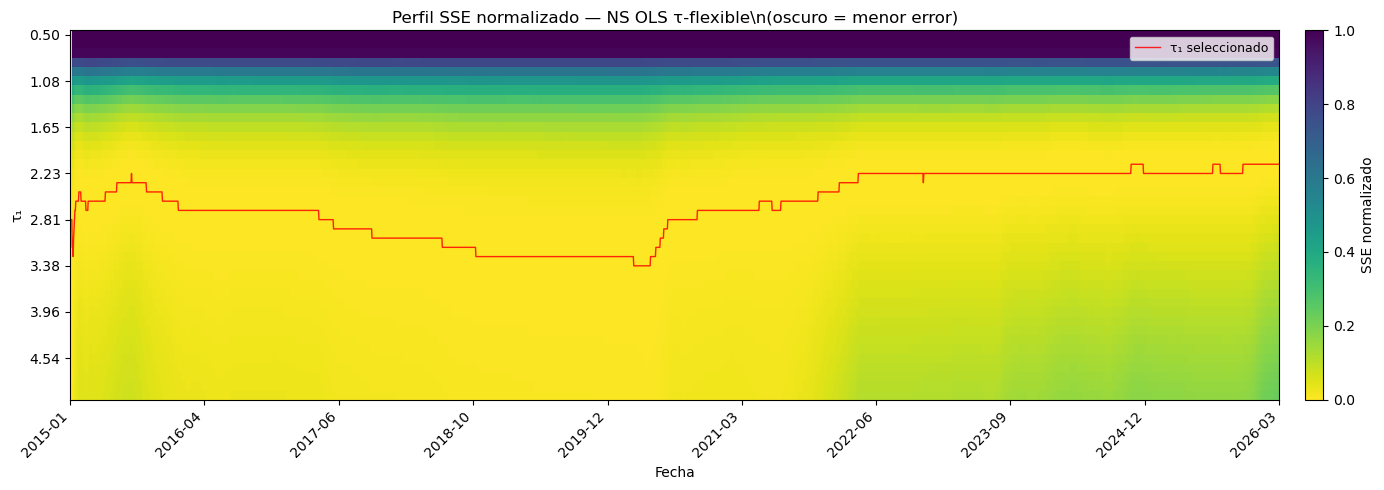

In [24]:
# ─── CELL 15: SSE profile heatmap ─────────────────────────────────────────────
## CELDA 14: Perfil SSE de τ en el tiempo (NS τ-flexible)")

def plot_perfil_sse_tau_ols(res):
    """Heatmap del perfil SSE(tau1, t) para NS τ-flexible (requiere re-ejecutar grid search)."""
    if res['model'] != 'NS' or res['tau_mode'] != 'flexible':
        print("Esta gráfica aplica solo a NS τ-flexible.")
        return

    tau1_g = np.linspace(0.5, 5.0, 40)
    print("Recalculando grid SSE para heatmap...")
    _, _, sse_grid = grid_search_tau_ns(res['yields'], res['maturities'], tau1_g)

    tau1_t = res['tau1_t']; dates = res['dates']; T = len(dates)

    sse_norm = np.zeros_like(sse_grid)
    for t in range(T):
        row = sse_grid[t]
        if np.any(~np.isnan(row)):
            lo, hi = np.nanpercentile(row, 5), np.nanpercentile(row, 95)
            sse_norm[t] = np.clip((row - lo) / (hi - lo + 1e-12), 0, 1)

    fig, ax = plt.subplots(figsize=(14, 5))
    im = ax.imshow(sse_norm.T, aspect='auto', cmap='viridis_r',
                   vmin=0, vmax=1, interpolation='nearest')
    ax.plot(range(T), [np.argmin(np.abs(tau1_g - t1)) for t1 in tau1_t],
            color='red', lw=1.0, alpha=0.85, label='τ₁ seleccionado')

    n_t = min(10, T//40+1)
    t_ticks = np.linspace(0, T-1, n_t, dtype=int)
    ax.set_xticks(t_ticks)
    ax.set_xticklabels([str(dates[i])[:7] for i in t_ticks], rotation=45, ha='right')
    ax.set_yticks(range(0, len(tau1_g), max(1, len(tau1_g)//8)))
    ax.set_yticklabels([f'{tau1_g[i]:.2f}' for i in range(0, len(tau1_g), max(1,len(tau1_g)//8))])
    ax.set_xlabel('Fecha'); ax.set_ylabel('τ₁')
    ax.set_title('Perfil SSE normalizado — NS OLS τ-flexible\\n(oscuro = menor error)')
    ax.legend(fontsize=9)
    plt.colorbar(im, ax=ax, fraction=0.025, pad=0.02, label='SSE normalizado')
    plt.tight_layout(); plt.show()


plot_perfil_sse_tau_ols(res_ns_flex)


